# Analisi benchmark LLM: reale vs teorico

**Obiettivo (tesi).** Questo notebook (1) offre una visione completa dei dati nei due CSV in `Benchmark_ML/Data/`, (2) confronta i risultati misurati con quelli del modello teorico di sizing (`llm-sizing-tool`), e (3) sviluppa una piccola pipeline di ML per provare a predire le metriche in modo piu accurato del modello teorico.

I due dataset:
- **`benchmark_results.csv`** - misure reali ottenute con vLLM (la *verita di campo*).
- **`sizing_results.csv`** - stime del modello teorico di sizing (la *predizione da battere*).

> Procediamo per step. Questo e lo **Step 1: caricamento e panoramica strutturale**.

In [ ]:
# Librerie necessarie per il notebook
%pip install numpy pandas matplotlib seaborn scikit-learn --quiet

# --- Setup ---
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 160)

# Data paths (relative to the Benchmark_ML folder)
DATA_DIR    = Path("Data")
BENCH_PATH  = DATA_DIR / "benchmark_results.csv"   # real measurements (vLLM)
SIZING_PATH = DATA_DIR / "sizing_results.csv"      # theoretical model (llm-sizing-tool)

# Experimental design factors and metrics of interest
DESIGN_FACTORS = ["model", "gpu_type", "tensor_parallelism",
                  "input_length", "output_length", "concurrent_users"]
METRICS = ["ttft_avg_ms", "itl_avg_ms", "request_latency_avg_ms",
           "output_token_throughput", "power_w"]
print("Setup OK")

## 1. Caricamento dei dati

Carichiamo i due file e verifichiamo che condividano lo stesso schema di colonne.

In [2]:
bench  = pd.read_csv(BENCH_PATH)
sizing = pd.read_csv(SIZING_PATH)

print(f"benchmark_results.csv : {bench.shape[0]:>3} rows x {bench.shape[1]} cols  (real measurements)")
print(f"sizing_results.csv    : {sizing.shape[0]:>3} rows x {sizing.shape[1]} cols  (theoretical model)")
print(f"\nIdentical column schema: {list(bench.columns) == list(sizing.columns)}")
bench.head(3)

benchmark_results.csv : 160 rows x 24 cols  (real measurements)
sizing_results.csv    : 310 rows x 24 cols  (theoretical model)

Identical column schema: True


,run_id,timestamp,run_tag,model,inference_framework,gpu_type,tensor_parallelism,input_length,input_std,output_length,concurrent_users,power_w,input_tokens,output_tokens,ttft_avg_ms,ttft_min_ms,ttft_max_ms,itl_avg_ms,itl_min_ms,itl_max_ms,request_latency_avg_ms,output_token_throughput,request_throughput,request_count
0,20260607_011120,2026-06-07 01:24:26,NaN,Llama-3.1-8B-Instruct,vllm,8x NVIDIA H100 PCIe,1,512,0,128,1,419.6,512.0,127.86,28.20,21.86,55.86,9.62,9.57,10.61,1248.00,102.12,0.80,500.0
1,20260607_011120,2026-06-07 01:24:26,NaN,Llama-3.1-8B-Instruct,vllm,8x NVIDIA H100 PCIe,1,512,0,128,10,424.6,512.0,127.95,120.82,29.54,2667.06,10.45,10.33,11.64,1447.71,879.68,6.88,500.0
2,20260607_011120,2026-06-07 01:24:26,NaN,Llama-3.1-8B-Instruct,vllm,8x NVIDIA H100 PCIe,1,512,0,128,50,425.2,512.0,127.96,328.33,47.53,2798.41,13.97,11.97,33.83,2101.70,2999.94,23.44,500.0


### 1.0 Coerenza dei dati: solo H100 PCIe e H200 NVLink, etichette GPU normalizzate

Il benchmark reale e stato eseguito **solo** su due GPU: **H100 PCIe** e **H200 NVLink (SXM)**. Il file teorico, invece, contiene anche H100 SXM e H200 PCIe. Per un confronto corretto, restringiamo da subito il file teorico alle stesse due GPU del benchmark.

Normalizziamo inoltre `gpu_type` alla **identita della GPU** (`H100 PCIe` / `H200 NVLink`) in entrambi i file: il prefisso `Nx` delle etichette grezze indica il **nodo** (8 GPU installate) nel reale e il **TP** nel teorico, ma in entrambi i casi le GPU effettivamente usate sono `tensor_parallelism` (TP=1 -> 1 GPU, TP=2 -> 2 GPU, ...), che resta il fattore sperimentale esplicito. Cosi i due dataset sono rappresentati allo stesso modo: **2 GPU x 4 TP**, non 8 pseudo-GPU. Tutto il resto del notebook lavora su questo sottoinsieme.

In [3]:
# --- Data consistency: keep only the GPUs present in the benchmark ---
# The real benchmark covers only H100 PCIe and H200 NVLink (SXM). We restrict
# the theoretical file to the same two GPU types so the comparison is fair.
def is_benchmark_gpu(g):
    g = str(g)
    if "H100" in g and "PCIe" in g:      # H100 PCIe
        return True
    if "H200" in g and "PCIe" not in g:  # H200 NVLink (SXM)
        return True
    return False

n_before = len(sizing)
sizing = sizing[sizing["gpu_type"].map(is_benchmark_gpu)].reset_index(drop=True)
print(f"Theoretical filtered to H100 PCIe / H200 NVLink: {n_before} -> {len(sizing)} rows")
print("Raw labels, real        :", sorted(bench["gpu_type"].unique()))
print("Raw labels, theoretical :", sorted(sizing["gpu_type"].unique()))

# Normalize gpu_type to the GPU IDENTITY in both files. The raw labels differ
# only in the "Nx" prefix: in the real file it is the node size (8 GPUs
# installed; a TP=k run uses k of them), in the theoretical file it is the TP
# itself. Either way the GPUs actually used = tensor_parallelism, which stays
# a design factor of its own, so the prefix carries no extra information and
# would otherwise show up in the plots as 8 pseudo-GPU series.
bench["gpu_type"]  = np.where(bench["gpu_type"].str.contains("H100"),  "H100 PCIe", "H200 NVLink")
sizing["gpu_type"] = np.where(sizing["gpu_type"].str.contains("H100"), "H100 PCIe", "H200 NVLink")
print("Normalized gpu_type     :", sorted(bench["gpu_type"].unique()), "(same in both files)")

Theoretical filtered to H100 PCIe / H200 NVLink: 310 -> 155 rows
Raw labels, real        : ['8x NVIDIA H100 PCIe', '8x NVIDIA H200']
Raw labels, theoretical : ['1x NVIDIA H100 PCIe', '1x NVIDIA H200', '2x NVIDIA H100 PCIe', '2x NVIDIA H200', '4x NVIDIA H100 PCIe', '4x NVIDIA H200', '8x NVIDIA H100 PCIe', '8x NVIDIA H200']
Normalized gpu_type     : ['H100 PCIe', 'H200 NVLink'] (same in both files)


### 1.1 Completezza delle colonne

Lo schema e identico, ma il file teorico **non popola** tutte le colonne (non ha min/max ne `request_throughput`). Vediamo quante celle non nulle ci sono per colonna in ciascun dataset.

In [4]:
# Non-null cells per column, in both datasets
completeness = pd.DataFrame({
    "bench_non_null":  bench.notna().sum(),
    "sizing_non_null": sizing.notna().sum(),
})
completeness["bench_%"]  = (completeness["bench_non_null"]  / len(bench)  * 100).round(0)
completeness["sizing_%"] = (completeness["sizing_non_null"] / len(sizing) * 100).round(0)
completeness

,bench_non_null,sizing_non_null,bench_%,sizing_%
run_id,160,155,100.0,100.0
timestamp,160,155,100.0,100.0
run_tag,0,0,0.0,0.0
model,160,155,100.0,100.0
inference_framework,160,0,100.0,0.0
gpu_type,160,155,100.0,100.0
tensor_parallelism,160,155,100.0,100.0
input_length,160,155,100.0,100.0
input_std,160,0,100.0,0.0
output_length,160,155,100.0,100.0


In [5]:
empty_sizing = [c for c in sizing.columns if sizing[c].isna().all()]
empty_bench  = [c for c in bench.columns  if bench[c].isna().all()]
print("Fully empty columns - THEORETICAL :", empty_sizing)
print("Fully empty columns - REAL        :", empty_bench)

# Comparable metrics = populated in BOTH files
comparable_metrics = [m for m in METRICS if bench[m].notna().any() and sizing[m].notna().any()]
print("\nComparable metrics (real vs theoretical):", comparable_metrics)

Fully empty columns - THEORETICAL : ['run_tag', 'inference_framework', 'input_std', 'ttft_min_ms', 'ttft_max_ms', 'itl_min_ms', 'itl_max_ms', 'request_throughput', 'request_count']
Fully empty columns - REAL        : ['run_tag']

Comparable metrics (real vs theoretical): ['ttft_avg_ms', 'itl_avg_ms', 'request_latency_avg_ms', 'output_token_throughput', 'power_w']


Da qui ricaviamo l'insieme delle **metriche confrontabili**: quelle popolate in *entrambi* i file. Saranno la base del confronto reale vs teorico (Step 3-4).

### 1.2 Copertura dello spazio sperimentale

Quali livelli assume ogni fattore sperimentale nei due dataset? Dopo la normalizzazione di 1.0, `gpu_type` ha gli **stessi 2 livelli** nei due file; il disallineamento residuo sono le config mancanti da un lato o dall'altro (il teorico salta quelle che non entrano in VRAM, il benchmark non ha eseguito alcune celle della griglia) - le quantificheremo nello Step 3.

In [6]:
# Unique levels of each design factor, in both datasets
def factor_levels(df):
    return {f: sorted(df[f].dropna().unique().tolist(), key=str) for f in DESIGN_FACTORS}

lev_b, lev_s = factor_levels(bench), factor_levels(sizing)
for f in DESIGN_FACTORS:
    print(f"\n{f}")
    print(f"  REAL        ({len(lev_b[f])}): {lev_b[f]}")
    print(f"  THEORETICAL ({len(lev_s[f])}): {lev_s[f]}")


model
  REAL        (6): ['DeepSeek-R1-Distill-Qwen-32B', 'Llama-3.1-8B-Instruct', 'Llama-3.3-70B-Instruct', 'Qwen2.5-32B-Instruct', 'Qwen2.5-7B-Instruct', 'gpt-oss-120b']
  THEORETICAL (6): ['DeepSeek-R1-Distill-Qwen-32B', 'Llama-3.1-8B-Instruct', 'Llama-3.3-70B-Instruct', 'Qwen2.5-32B-Instruct', 'Qwen2.5-7B-Instruct', 'gpt-oss-120b']

gpu_type
  REAL        (2): ['H100 PCIe', 'H200 NVLink']
  THEORETICAL (2): ['H100 PCIe', 'H200 NVLink']

tensor_parallelism
  REAL        (4): [1, 2, 4, 8]
  THEORETICAL (4): [1, 2, 4, 8]

input_length
  REAL        (1): [512]
  THEORETICAL (1): [512]

output_length
  REAL        (1): [128]
  THEORETICAL (1): [128]

concurrent_users
  REAL        (4): [1, 10, 100, 50]
  THEORETICAL (4): [1, 10, 100, 50]


In [7]:
# Number of runs per model in each dataset
counts = pd.concat([
    bench.groupby("model").size().rename("bench"),
    sizing.groupby("model").size().rename("sizing"),
], axis=1)
counts

,bench,sizing
model,,
DeepSeek-R1-Distill-Qwen-32B,28,28
Llama-3.1-8B-Instruct,32,31
Llama-3.3-70B-Instruct,24,20
Qwen2.5-32B-Instruct,32,28
Qwen2.5-7B-Instruct,24,31
gpt-oss-120b,20,17


### 1.3 Statistiche descrittive delle metriche

Distribuzione (media, deviazione, quartili) delle metriche chiave nei due dataset, per avere un primo ordine di grandezza dei valori e degli outlier.

In [8]:
print("REAL - descriptive statistics of metrics")
display(bench[METRICS].describe().T.round(2))
print("\nTHEORETICAL - descriptive statistics of metrics")
display(sizing[comparable_metrics].describe().T.round(2))

REAL - descriptive statistics of metrics


,count,mean,std,min,25%,50%,75%,max
ttft_avg_ms,160.0,1494.38,3091.36,17.00,140.42,533.68,1630.35,23633.84
itl_avg_ms,160.0,29.22,37.77,3.08,9.28,19.20,35.89,364.70
request_latency_avg_ms,160.0,5184.85,6625.30,409.65,1441.86,2927.29,5725.16,50086.01
output_token_throughput,160.0,1294.27,1560.95,21.01,220.68,741.18,1727.49,7908.81
power_w,160.0,663.39,167.92,416.80,521.22,661.70,760.58,1000.20



THEORETICAL - descriptive statistics of metrics


,count,mean,std,min,25%,50%,75%,max
ttft_avg_ms,155.0,1028.02,1810.16,4.43,74.70,312.82,942.44,12371.00
itl_avg_ms,155.0,20.76,21.49,1.15,5.26,13.13,30.08,84.27
request_latency_avg_ms,155.0,3684.76,4106.47,151.33,896.14,2232.49,4842.00,21560.06
output_token_throughput,155.0,112.32,137.36,5.94,26.44,57.33,142.84,845.83
power_w,155.0,2294.19,1645.59,350.00,1400.00,1400.00,2800.00,5600.00


## 2. Visualizzazioni esplorative

Guardiamo i due dataset **separatamente**: prima capiamo ciascuno per conto suo, poi (Step 3-4) li allineeremo e confronteremo. Gia mettendo a fianco le due serie di grafici emerge la differenza di *forma* tra reale e teorico - in particolare sul throughput.

### 2.1 Distribuzioni delle metriche (reale)

Boxplot delle 5 metriche confrontabili nel benchmark reale, per modello e GPU: serve a vedere range, mediana e outlier prima di guardare gli andamenti.

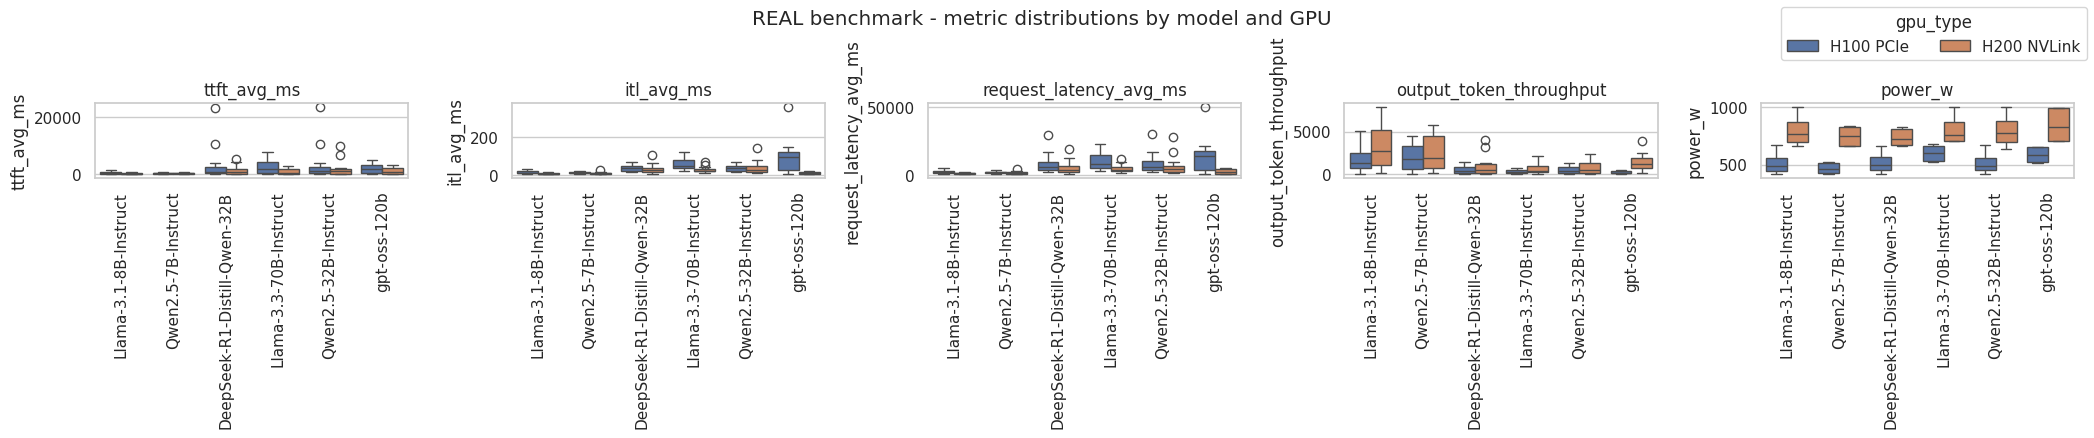

In [9]:
# Distribution of the comparable metrics in the REAL benchmark, split by GPU
fig, axes = plt.subplots(1, len(METRICS), figsize=(4.2 * len(METRICS), 4.2))
for ax, m in zip(axes, METRICS):
    sns.boxplot(data=bench, x="model", y=m, hue="gpu_type", ax=ax)
    ax.set_title(m)
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=90)
    ax.legend_.remove() if ax.get_legend() else None
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper right", ncol=2, title="gpu_type")
fig.suptitle("REAL benchmark - metric distributions by model and GPU", y=1.04)
plt.tight_layout()
plt.show()

### 2.2 Andamenti rispetto alla concurrency

Per ogni metrica tracciamo l'andamento al crescere degli utenti concorrenti, un pannello per modello (**colore = TP**, **tratteggio/marker = GPU**; stesse serie 2 GPU x 4 TP nei due dataset, grazie alla normalizzazione di 1.0). Mostriamo **reale e teorico separatamente**: confrontare i due grafici e gia un primo risultato. `power_w` fa eccezione: essendo quasi piatta rispetto alla concurrency, la mostriamo come **grafico a barre** per GPU e TP (media sulla concurrency, barre d'errore = deviazione standard), dove emergono i gradini per TP, la sub-linearita del consumo reale per-GPU e il divario con la targa teorica (`tdp x n_gpu`).

> **Da osservare:** sul throughput le due curve vanno in **direzioni opposte** - il reale *cresce* con la concurrency (e' il throughput **aggregato** del sistema, che beneficia del batching di vLLM), il teorico *cala* (e' `N_out / latenza` della **singola richiesta**, la cui latenza cresce con `C` per coda e contention). Non e' un errore del modello ma una differenza di definizione: per questo nello Step 4 il confronto quantitativo usera TTFT/ITL (approccio c) e tratteremo il throughput a parte.

In [10]:
def trend(df, metric, title):
    """Line plot of `metric` vs concurrency, one panel per model.
    Colour = TP (distinct colors, fixed order), dash/marker = GPU identity:
    the same 2 GPU x 4 TP series in the real and theoretical plots."""
    d = df.assign(TP=df["tensor_parallelism"].astype(int).astype(str))
    g = sns.relplot(
        data=d, x="concurrent_users", y=metric,
        col="model", col_wrap=3,
        hue="TP", hue_order=["1", "2", "4", "8"], palette="tab10",
        style="gpu_type", markers=True, dashes=True,
        kind="line", height=3, aspect=1.25,
        facet_kws={"sharey": False},
    )
    g.set_titles("{col_name}")
    g.figure.suptitle(title, y=1.02)
    for ax in g.axes.flat:
        ax.set_xlabel("concurrent users")
        ax.grid(True, alpha=0.3)
    plt.show()

def bars(df, metric, title):
    """Bar plot of `metric` by GPU and TP, one panel per model, averaged over
    the concurrency levels (error bars = std across concurrency: tiny when the
    metric is ~flat in C). Colour = TP, same palette/order as trend()."""
    d = df.assign(TP=df["tensor_parallelism"].astype(int).astype(str))
    g = sns.catplot(
        data=d, x="gpu_type", y=metric,
        col="model", col_wrap=3,
        hue="TP", hue_order=["1", "2", "4", "8"], palette="tab10",
        kind="bar", errorbar="sd", height=3, aspect=1.25,
    )
    g.set_titles("{col_name}")
    g.figure.suptitle(title, y=1.02)
    for ax in g.axes.flat:
        ax.set_xlabel("")
        ax.grid(True, axis="y", alpha=0.3)
    plt.show()

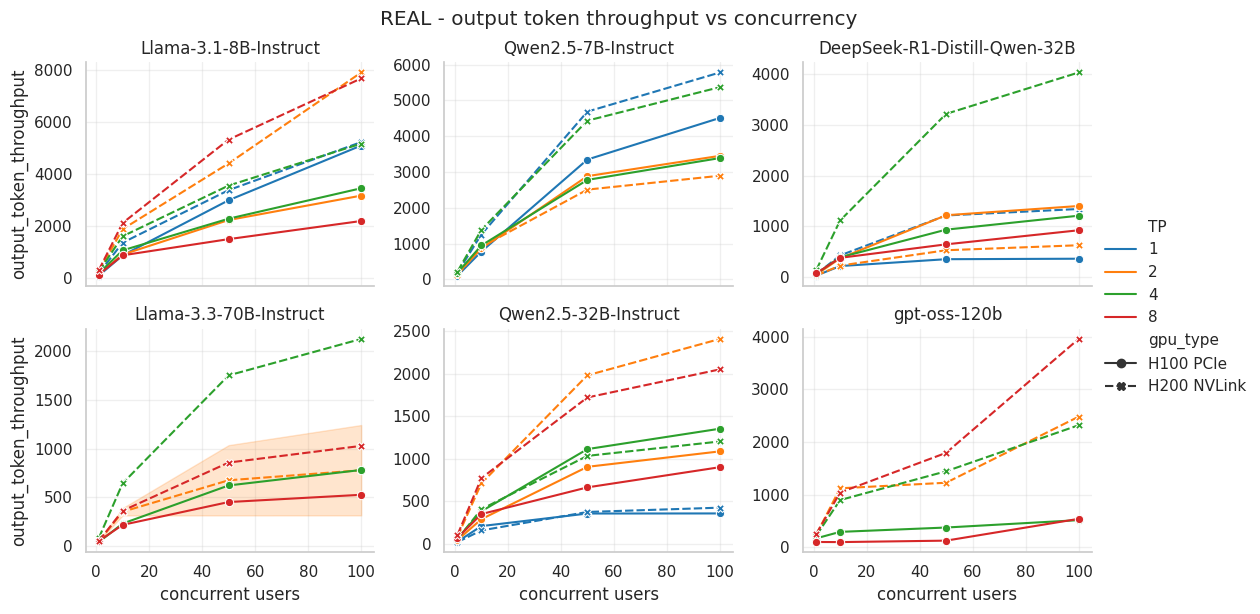

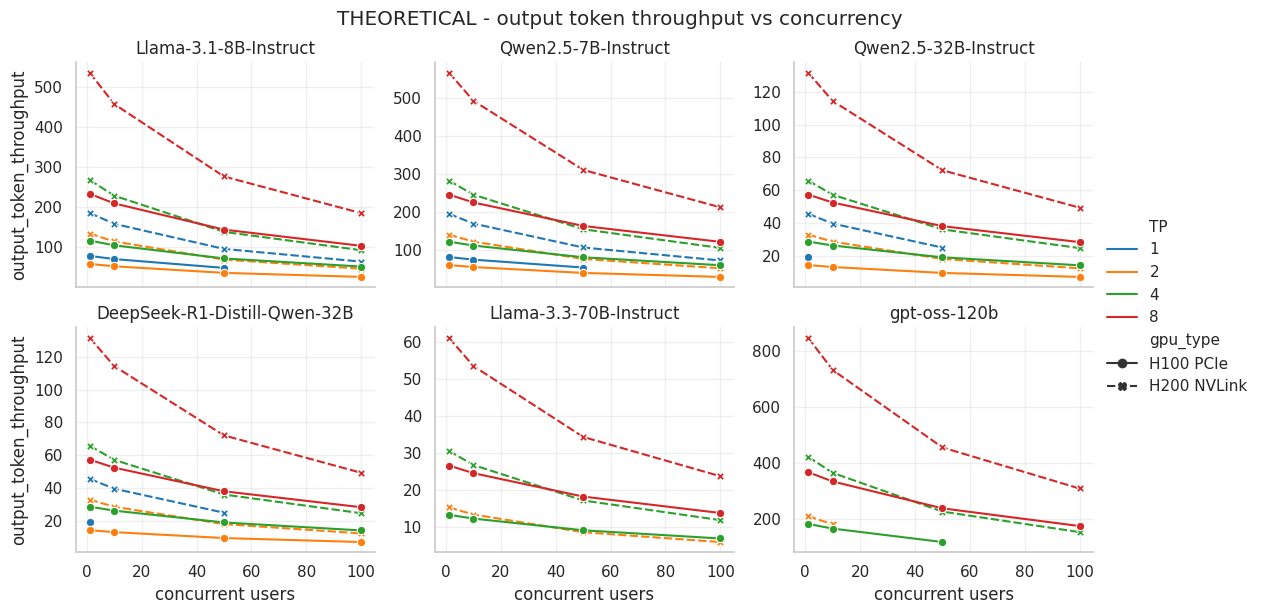

In [11]:
# Headline metric: throughput. Watch the OPPOSITE direction vs concurrency.
trend(bench,  "output_token_throughput", "REAL - output token throughput vs concurrency")
trend(sizing, "output_token_throughput", "THEORETICAL - output token throughput vs concurrency")

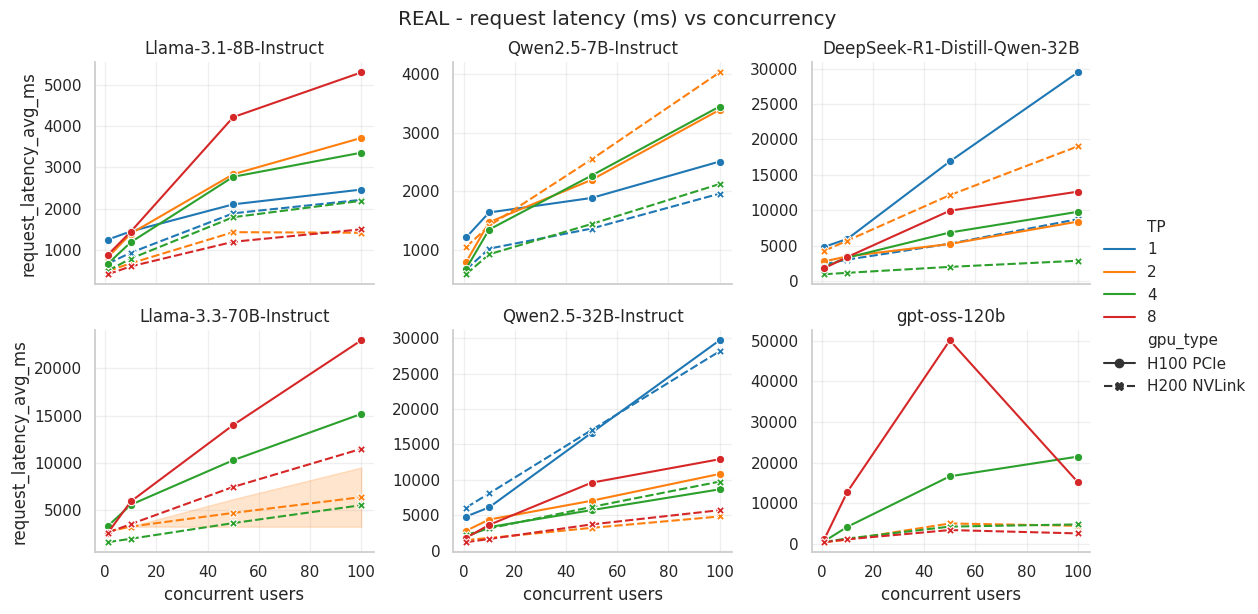

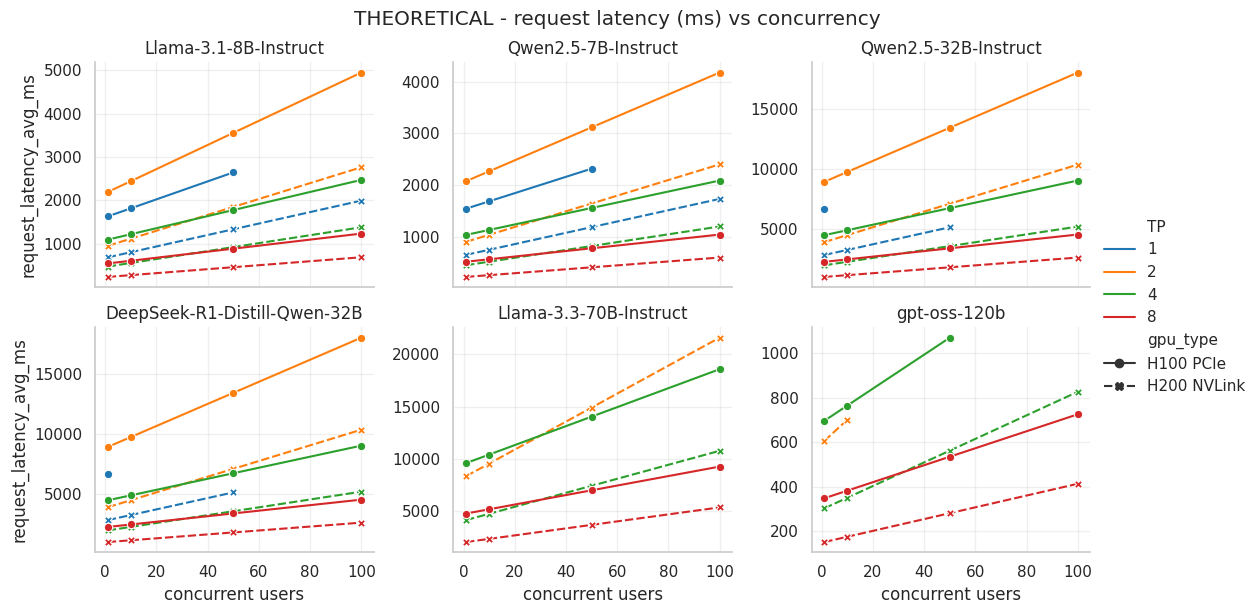

In [12]:
trend(bench,  "request_latency_avg_ms", "REAL - request latency (ms) vs concurrency")
trend(sizing, "request_latency_avg_ms", "THEORETICAL - request latency (ms) vs concurrency")

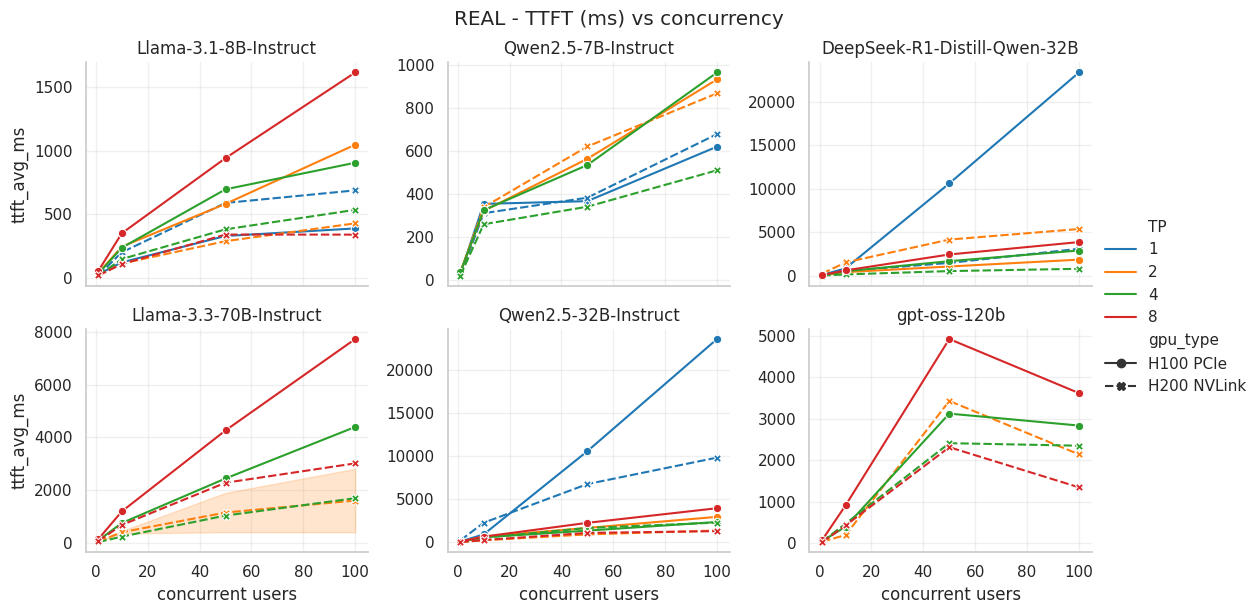

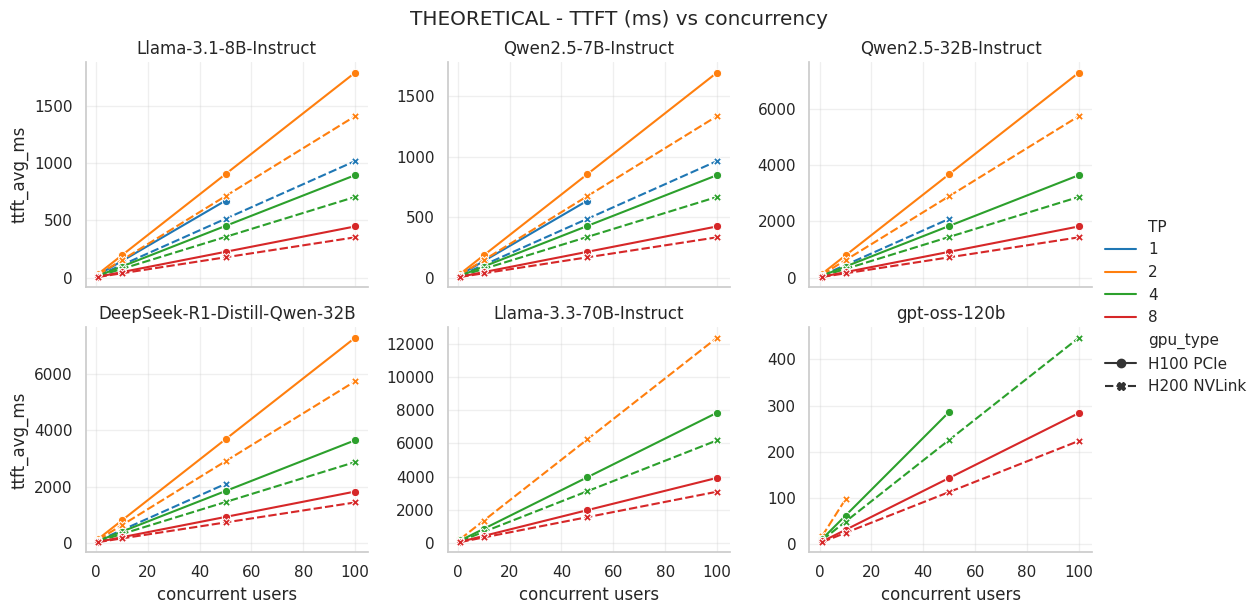

In [13]:
trend(bench,  "ttft_avg_ms", "REAL - TTFT (ms) vs concurrency")
trend(sizing, "ttft_avg_ms", "THEORETICAL - TTFT (ms) vs concurrency")

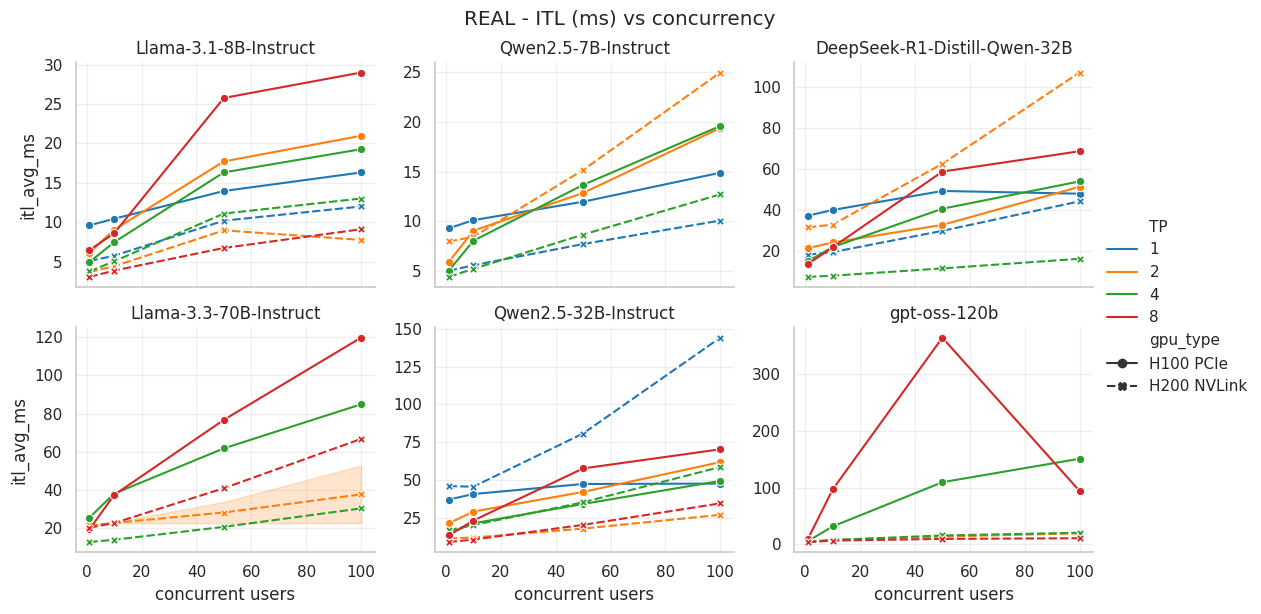

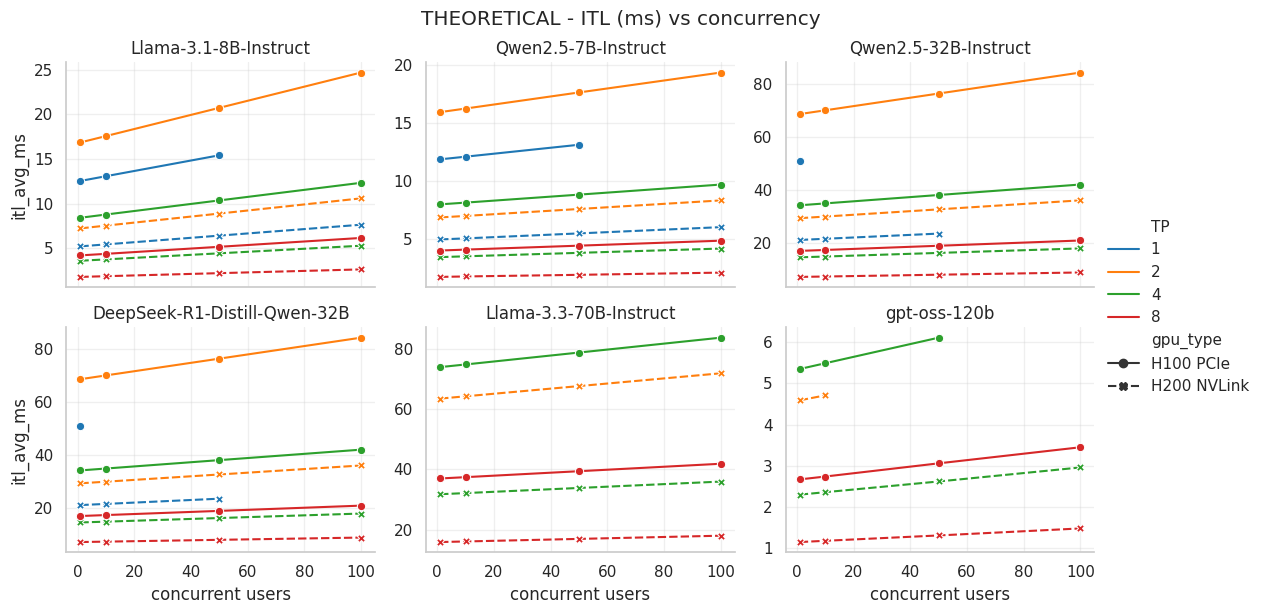

In [14]:
trend(bench,  "itl_avg_ms", "REAL - ITL (ms) vs concurrency")
trend(sizing, "itl_avg_ms", "THEORETICAL - ITL (ms) vs concurrency")

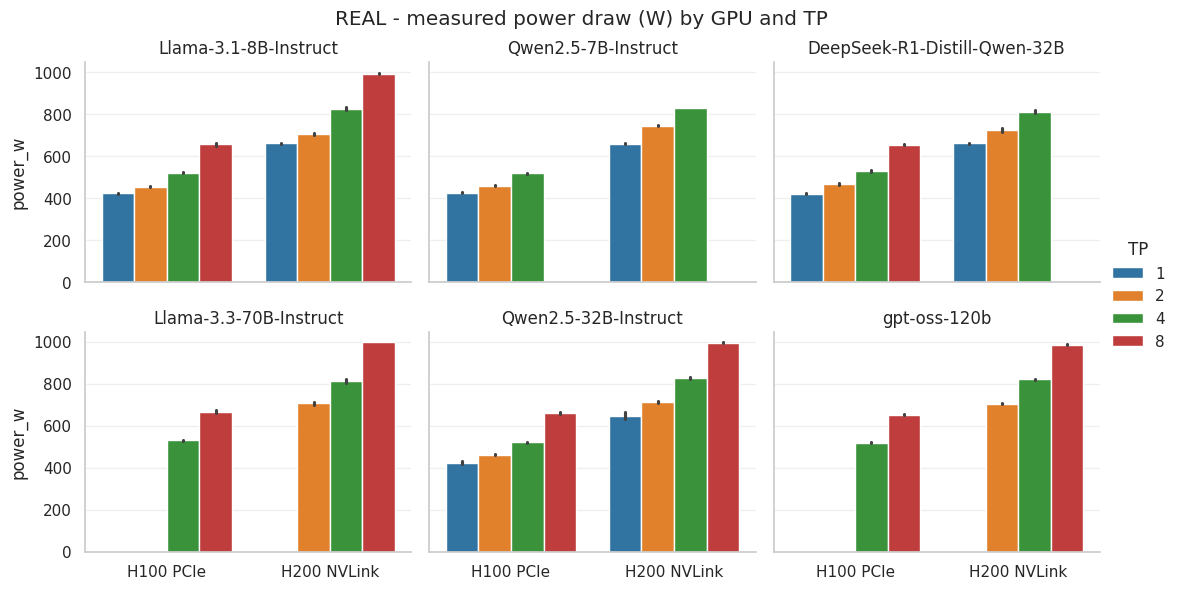

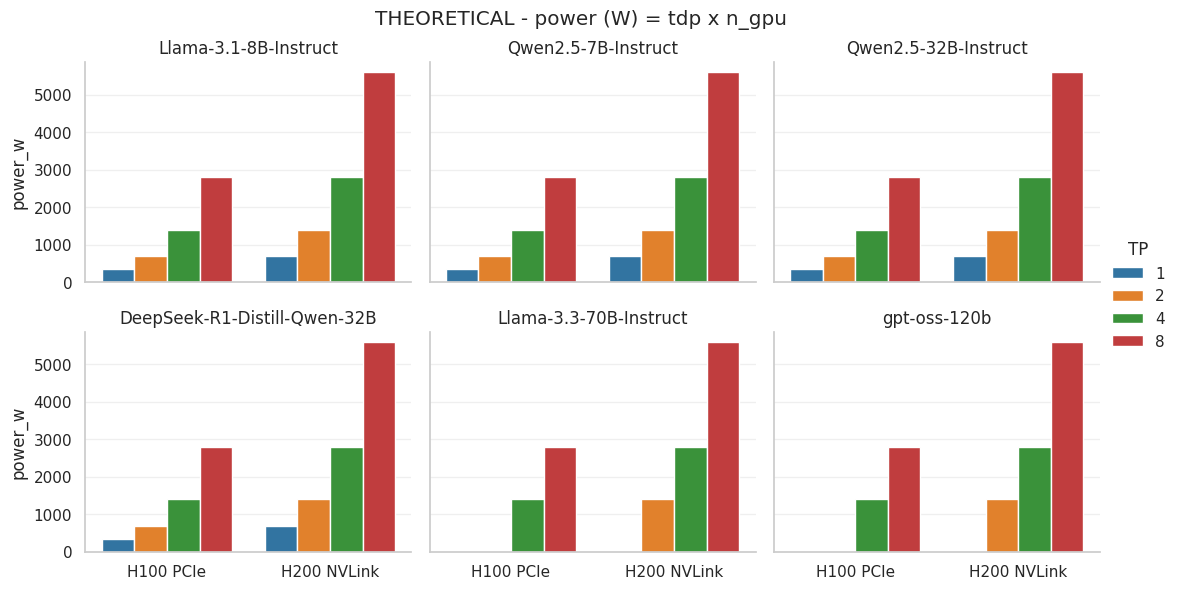

In [15]:
# Power is ~flat vs concurrency, so lines add nothing: bar chart by GPU and TP,
# averaged over concurrency (error bars = std across C, indeed tiny). Note the
# gap between the measured draw and the theoretical nameplate (tdp x n_gpu),
# and how the REAL per-GPU draw is sub-linear in TP.
bars(bench,  "power_w", "REAL - measured power draw (W) by GPU and TP")
bars(sizing, "power_w", "THEORETICAL - power (W) = tdp x n_gpu")

## 3. Allineamento dei dataset

Per confrontare reale e teorico servono **chiavi comuni**. I nomi modello sono gia identici (sistemati alla fonte) e `gpu_type` e gia stato normalizzato all'identita della GPU (1.0). Scomponiamo l'identita in **architettura** (H100/H200) e **interconnessione** (PCIe/NVLink) e allineiamo sul **numero effettivo di GPU = TP** (in entrambi i file le GPU usate sono `tensor_parallelism`).

Chiave di join: `(model, gpu_arch, interconnect, n_gpu, concurrent_users)`. Input/output sono fissi (512->128), quindi non entrano nella chiave.

### 3.1 Chiavi e aggregazione

Una configurazione e identificata univocamente dalle chiavi. I run ripetuti lato reale (4 righe duplicate) vengono mediati -> 156 config distinte; lato teorico l'operazione e un no-op (una riga per config).

In [16]:
# gpu_type was normalized to the GPU identity in step 1.0; in BOTH files the
# GPUs actually used = tensor_parallelism (confirmed: a real TP=k run uses k
# of the node's 8 GPUs). We decompose the identity into architecture and
# interconnect and align on the effective GPU count n_gpu = TP.
def add_keys(df):
    df = df.copy()
    g = df["gpu_type"].astype(str)
    df["gpu_arch"]     = np.where(g.str.contains("H100"), "H100", "H200")
    df["interconnect"] = np.where(g.str.contains("PCIe"), "PCIe", "NVLink")
    df["n_gpu"]        = df["tensor_parallelism"].astype(int)
    return df

KEYS = ["model", "gpu_arch", "interconnect", "n_gpu", "concurrent_users"]
bench_k, sizing_k = add_keys(bench), add_keys(sizing)
bench_k[["model", "gpu_type", "gpu_arch", "interconnect", "n_gpu", "concurrent_users"]].head()

,model,gpu_type,gpu_arch,interconnect,n_gpu,concurrent_users
0,Llama-3.1-8B-Instruct,H100 PCIe,H100,PCIe,1,1
1,Llama-3.1-8B-Instruct,H100 PCIe,H100,PCIe,1,10
2,Llama-3.1-8B-Instruct,H100 PCIe,H100,PCIe,1,50
3,Llama-3.1-8B-Instruct,H100 PCIe,H100,PCIe,1,100
4,Llama-3.1-8B-Instruct,H100 PCIe,H100,PCIe,2,1


In [17]:
# A config is fully identified by KEYS (input/output are fixed at 512->128).
# Collapse any repeated runs by averaging the comparable metrics
# (deterministic / a no-op for the theoretical file).
dup_real = bench_k.duplicated(KEYS).sum()
dup_theo = sizing_k.duplicated(KEYS).sum()
print(f"Duplicate-key rows  ->  real: {dup_real}  |  theoretical: {dup_theo}")

real_agg = bench_k.groupby(KEYS, as_index=False)[comparable_metrics].mean()
theo_agg = sizing_k.groupby(KEYS, as_index=False)[comparable_metrics].mean()
print(f"Distinct configs    ->  real: {len(real_agg)}  |  theoretical: {len(theo_agg)}")

Duplicate-key rows  ->  real: 4  |  theoretical: 0
Distinct configs    ->  real: 156  |  theoretical: 155


### 3.2 Dataset appaiato (inner join)

Uniamo le due tabelle config-per-config. Il risultato (`paired`) ha le chiavi piu ogni metrica nelle due varianti `_real` / `_theo`: e la base per il confronto dello Step 4 e per la pipeline ML.

In [18]:
# Inner join: paired real <-> theoretical for the same config.
paired = real_agg.merge(theo_agg, on=KEYS, suffixes=("_real", "_theo"))
print(f"Paired configs (inner join): {len(paired)}")
paired.head()

Paired configs (inner join): 143


,model,gpu_arch,interconnect,n_gpu,concurrent_users,ttft_avg_ms_real,itl_avg_ms_real,request_latency_avg_ms_real,output_token_throughput_real,power_w_real,ttft_avg_ms_theo,itl_avg_ms_theo,request_latency_avg_ms_theo,output_token_throughput_theo,power_w_theo
0,DeepSeek-R1-Distill-Qwen-32B,H100,PCIe,1,1,97.57,37.18,4818.92,26.54,417.0,107.45,51.07,6644.69,19.26,350.0
1,DeepSeek-R1-Distill-Qwen-32B,H100,PCIe,2,1,60.50,21.25,2759.09,46.32,458.9,144.43,68.65,8931.03,14.33,700.0
2,DeepSeek-R1-Distill-Qwen-32B,H100,PCIe,2,10,418.59,24.05,3472.70,367.92,467.1,794.35,70.07,9762.76,13.11,700.0
3,DeepSeek-R1-Distill-Qwen-32B,H100,PCIe,2,50,1070.37,32.68,5220.27,1218.25,469.8,3682.91,76.38,13459.32,9.51,700.0
4,DeepSeek-R1-Distill-Qwen-32B,H100,PCIe,2,100,1858.73,51.32,8376.91,1400.40,470.0,7293.60,84.27,18080.03,7.08,700.0


### 3.3 Copertura: cosa non si appaia (e perche)

L'inner join scarta le config presenti in un solo file. Lato reale restano fuori 13 config che il tool considera **infeasible per VRAM** (`SKIP_INFEASIBLE`): pesi FP16 che non entrano a TP basso (es. Llama-70B a TP=1, gpt-oss-120b che in realta gira quantizzato MXFP4 mentre il tool lo modella FP16) o KV cache che non entra ad alta concurrency. Lato teorico restano fuori 12 config TP=8 che il benchmark non ha eseguito. Quantifichiamo gli scarti per non scoprirli a sorpresa nel confronto.

In [19]:
# What did NOT pair, and why.
real_only = real_agg.merge(theo_agg[KEYS], on=KEYS, how="left", indicator=True)
real_only = real_only[real_only["_merge"] == "left_only"]
theo_only = theo_agg.merge(real_agg[KEYS], on=KEYS, how="left", indicator=True)
theo_only = theo_only[theo_only["_merge"] == "left_only"]

print(f"Real configs WITHOUT theoretical match : {len(real_only)}")
print("   by n_gpu (TP)        :", real_only["n_gpu"].value_counts().sort_index().to_dict())
print("   by concurrent_users  :", real_only["concurrent_users"].value_counts().sort_index().to_dict())
print(f"\nTheoretical configs WITHOUT real match : {len(theo_only)}")
print("   by n_gpu (TP)        :", theo_only["n_gpu"].value_counts().sort_index().to_dict())
print("   by concurrent_users  :", theo_only["concurrent_users"].value_counts().sort_index().to_dict())

print("\nPaired set coverage across design factors:")
for k in ["model", "gpu_arch", "interconnect", "n_gpu", "concurrent_users"]:
    print(f"   {k:18s}: {sorted(paired[k].unique().tolist())}")

Real configs WITHOUT theoretical match : 13
   by n_gpu (TP)        : {1: 10, 2: 2, 4: 1}
   by concurrent_users  : {10: 2, 50: 3, 100: 8}

Theoretical configs WITHOUT real match : 12
   by n_gpu (TP)        : {8: 12}
   by concurrent_users  : {1: 3, 10: 3, 50: 3, 100: 3}

Paired set coverage across design factors:
   model             : ['DeepSeek-R1-Distill-Qwen-32B', 'Llama-3.1-8B-Instruct', 'Llama-3.3-70B-Instruct', 'Qwen2.5-32B-Instruct', 'Qwen2.5-7B-Instruct', 'gpt-oss-120b']
   gpu_arch          : ['H100', 'H200']
   interconnect      : ['NVLink', 'PCIe']
   n_gpu             : [1, 2, 4, 8]
   concurrent_users  : [1, 10, 50, 100]


## 4. Confronto reale vs teorico

### 4.0 Come il modello teorico calcola le metriche (box metodologico)

Il `llm-sizing-tool` (`backend/gpu_calc.py` + `config.py:PERF_MODEL`) stima le metriche con un modello **roofline calibrato**. Con `P_att` = parametri attivi (miliardi; per i MoE solo gli expert attivati), `BW` = banda memoria (GB/s), `FLOPS` = TFLOPS FP16 *dense*, `C` = utenti concorrenti, `N_in/N_out` = token, `n` = numero GPU (= TP):

```
eta        = 1 se n=1, altrimenti 0.361 (NVLink) / 0.372 (PCIe)   # efficienza scaling TP
FLOPS_eff  = n x FLOPS x MFU x eta          con MFU = 0.413
BW_eff     = n x BW x MBU x eta             con MBU = 0.643

TTFT = 2 P_att N_in / FLOPS_eff x (C+1)/2               # coda closed-loop media
ITL  = max( (pesi_att + KV_batch) / BW_eff ,            # banda: pesi + KV di tutto il batch
            2 P_att C / FLOPS_eff )                     # compute del batch
request_latency_avg_ms  = TTFT + N_out x ITL
output_token_throughput = N_out / (request_latency_avg_ms / 1000)   # per SINGOLA richiesta
```

Le **stesse formule valgono per entrambi gli interconnect**: cambiano solo `eta` e le spec GPU (H100 = profilo *PCIe*: 756 TFLOPS dense, 2.0 TB/s; H200 = SXM/NVLink: 989 TFLOPS, 4.8 TB/s). `KV_batch` e la KV cache di tutto il batch al contesto medio (`N_in + N_out/2`).

> **Caveat di calibrazione (da dichiarare in tesi).** I 4 parametri liberi (`MFU`, `MBU`, `eta` x2) sono stati **fittati su questo stesso dataset** (`calibrate_perf_model.py`, minimizzazione del log-errore su TTFT+ITL, **soli modelli densi**: gpt-oss e escluso dal fit perche il roofline con i 5.1B attivi della model card lo sottostima ~5x, vedi il box MoE in 6.1). Gli errori dello Step 4 sono quindi residui *in-sample*: misurano quanto la *struttura* del modello spiega i dati una volta rimosso il bias, non la generalizzazione.

**Due conseguenze semantiche da tenere a mente nel confronto:**
1. **`output_token_throughput`** teorico e *per singola richiesta* ed e collineare con la latenza (`= N_out/latenza`); quello reale e *aggregato di sistema*. Crescono in direzioni opposte con la concurrency.
2. **Concurrency**: il modello la tratta con il fattore di coda `(C+1)/2` sul TTFT (validato dal fit: esponente ottimo ~0.97) e con la lettura KV del batch nell'ITL; il fit esteso indica pero che la **contention reale del decode e ~4x piu forte** del termine KV puro - residuo strutturale noto.

Procediamo in tre parti: **(4.1)** confronto *as-is* su tutte le metriche, **(4.2)** approccio *(b)* per il throughput, **(4.3)** confronto quantitativo *(c)* sulle metriche pulite TTFT/ITL.

In [20]:
# Error convention: error = theoretical - real  (positive => theory OVERestimates).
err = paired.copy()
for m in comparable_metrics:
    err[f"{m}__err"] = err[f"{m}_theo"] - err[f"{m}_real"]
    err[f"{m}__pe"]  = (err[f"{m}_theo"] - err[f"{m}_real"]) / err[f"{m}_real"] * 100

def error_summary(df, metrics):
    out = []
    for m in metrics:
        pe = df[f"{m}__pe"]; ae = df[f"{m}__err"].abs()
        out.append({"metric": m, "n": int(df[f"{m}_real"].notna().sum()),
                    "MAE": ae.mean(), "MAPE_%": pe.abs().mean(), "bias_%": pe.mean()})
    return pd.DataFrame(out).set_index("metric").round(2)

def scatter_vs(df, metrics, title, hue="concurrent_users", log=False, savepath=None):
    fig, axes = plt.subplots(1, len(metrics), figsize=(4.3 * len(metrics), 4))
    axes = np.atleast_1d(axes)
    for ax, m in zip(axes, metrics):
        sns.scatterplot(data=df, x=f"{m}_real", y=f"{m}_theo", hue=hue,
                        palette="viridis" if hue == "concurrent_users" else "tab10",
                        s=40, ax=ax, legend=(ax is axes[-1]))
        lo = float(np.nanmin([df[f"{m}_real"].min(), df[f"{m}_theo"].min()]))
        hi = float(np.nanmax([df[f"{m}_real"].max(), df[f"{m}_theo"].max()]))
        if log:
            lo = max(lo, 1e-2)
            ax.set_xscale("log"); ax.set_yscale("log")
        ax.plot([lo, hi], [lo, hi], "k--", lw=1, alpha=0.6)
        ax.set(title=m, xlabel="real (measured)", ylabel="theoretical (predicted)")
    fig.suptitle(title, y=1.04)
    plt.tight_layout()
    if savepath:
        fig.savefig(savepath, dpi=150, bbox_inches="tight")
    plt.show()

### 4.1 Confronto "as-is" (didattico)

Confrontiamo direttamente predetto-vs-misurato su **tutte** le metriche, *senza* correzioni. Convenzione: `errore = teorico - reale` (positivo => il teorico sovrastima). Sulle metriche per-token (TTFT/ITL) e sulla latenza l'errore e ora dello stesso ordine (~60-75% MAPE, residuo post-calibrazione); restano fuorvianti il **throughput** (definizioni diverse, vedi 4.0: bias ~-64% perche il per-richiesta teorico e confrontato con l'aggregato reale) e **power_w** (targa `tdp x n` vs consumo misurato, MAPE ~186%).

In [21]:
print("AS-IS: theoretical vs real on ALL comparable metrics (paired configs)")
print("bias_% > 0 => theory overestimates. Huge MAPE on throughput/latency = different quantities.\n")
error_summary(err, comparable_metrics)

AS-IS: theoretical vs real on ALL comparable metrics (paired configs)
bias_% > 0 => theory overestimates. Huge MAPE on throughput/latency = different quantities.



,n,MAE,MAPE_%,bias_%
metric,,,,
ttft_avg_ms,143,812.23,75.33,16.50
itl_avg_ms,143,17.95,59.97,7.03
request_latency_avg_ms,143,2990.98,63.02,13.99
output_token_throughput,143,1237.29,82.13,-63.59
power_w,143,1427.16,186.52,184.60


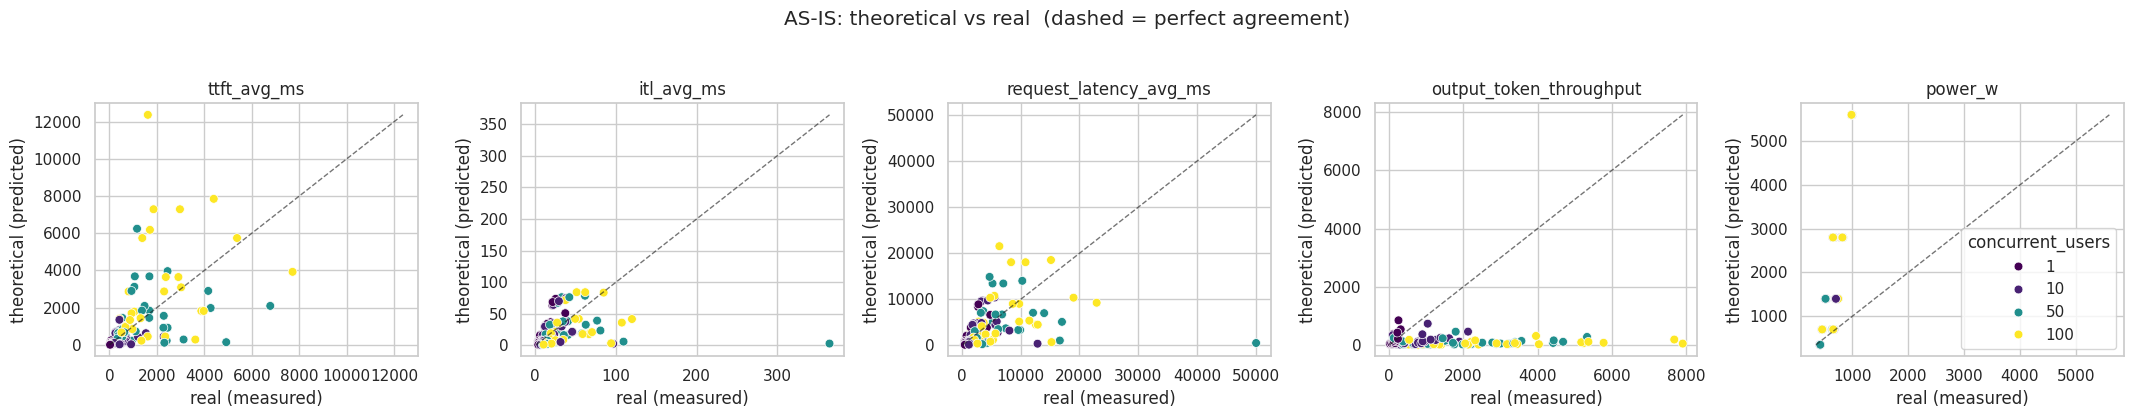

In [22]:
scatter_vs(err, comparable_metrics, "AS-IS: theoretical vs real  (dashed = perfect agreement)")

### 4.2 Approccio (b): throughput per-richiesta

Il throughput reale e aggregato; quello teorico e per-richiesta. Per renderli confrontabili dividiamo il reale per il numero di utenti (`throughput_reale / C`). Risultato: la MAPE **resta ~80%** (cambia il segno e la struttura dell'errore, non la grandezza complessiva) - la differenza tra le due quantita non e un semplice fattore di scala, perche il batching reale di vLLM serve C utenti quasi al costo di uno mentre il modello teorico ripartisce coda e contention sulla singola richiesta. La lezione didattica resta: throughput aggregato e per-richiesta sono mondi diversi, e il confronto pulito va fatto su TTFT/ITL.

Throughput MAPE  as-is (real = aggregate)   :     82.1 %
Throughput MAPE  approach (b) per-request   :    212.8 %


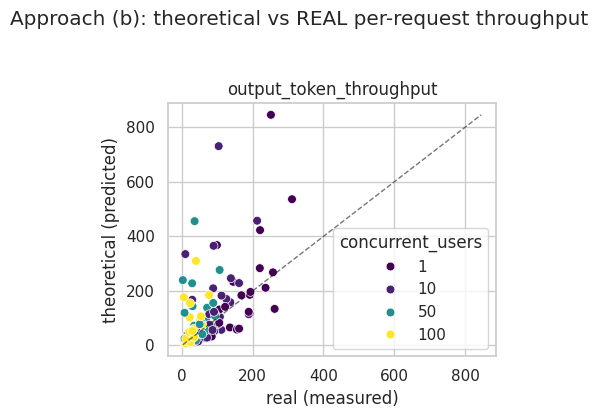

In [23]:
# Approach (b): convert REAL aggregate throughput to per-request, matching the
# theoretical definition (N_out / single-request latency).
bdf = err.copy()
bdf["output_token_throughput_real"] = bdf["output_token_throughput_real"] / bdf["concurrent_users"]
bdf["output_token_throughput__pe"]  = ((bdf["output_token_throughput_theo"] - bdf["output_token_throughput_real"])
                                       / bdf["output_token_throughput_real"] * 100)

asis  = err["output_token_throughput__pe"].abs().mean()
normb = bdf["output_token_throughput__pe"].abs().mean()
print(f"Throughput MAPE  as-is (real = aggregate)   : {asis:8.1f} %")
print(f"Throughput MAPE  approach (b) per-request   : {normb:8.1f} %")
scatter_vs(bdf, ["output_token_throughput"],
           "Approach (b): theoretical vs REAL per-request throughput")

### 4.3 Confronto quantitativo (c): TTFT e ITL

Questo e il confronto *legittimo*: le metriche per-token (TTFT, ITL) hanno definizione coerente tra i due file. Misuriamo MAE, MAPE e bias, prima su tutte le config appaiate poi a `C = 1`, e scomponiamo l'errore per concurrency, interconnessione e modello. Aspettativa post-calibrazione: errore **senza trend esplosivi in C** (coda e contention sono modellate) e **simile sui due interconnect**; il residuo e varianza per-modello, non bias sistematico.

In [24]:
clean = ["ttft_avg_ms", "itl_avg_ms"]
print("Approach (c) - quantitative comparison on clean per-token metrics\n")
print("All paired configs:")
display(error_summary(err, clean))
print("Concurrency = 1 only (definitions align best):")
display(error_summary(err[err["concurrent_users"] == 1], clean))

Approach (c) - quantitative comparison on clean per-token metrics

All paired configs:


,n,MAE,MAPE_%,bias_%
metric,,,,
ttft_avg_ms,143,812.23,75.33,16.50
itl_avg_ms,143,17.95,59.97,7.03


Concurrency = 1 only (definitions align best):


,n,MAE,MAPE_%,bias_%
metric,,,,
ttft_avg_ms,39,37.30,55.26,-1.98
itl_avg_ms,39,10.62,72.16,50.41


In [25]:
def mape_by(df, by):
    cols = ["ttft_avg_ms__pe", "itl_avg_ms__pe"]
    g = df.groupby(by)[cols].apply(lambda d: pd.Series({
        "TTFT_MAPE_%": d["ttft_avg_ms__pe"].abs().mean(),
        "ITL_MAPE_%":  d["itl_avg_ms__pe"].abs().mean(),
        "n": len(d),
    }))
    g["n"] = g["n"].astype(int)
    return g.round(1)

print("TTFT/ITL error by concurrency:");  display(mape_by(err, "concurrent_users"))
print("by interconnect (H100/PCIe vs H200/NVLink):"); display(mape_by(err, "interconnect"))
print("by model:");                       display(mape_by(err, "model"))

TTFT/ITL error by concurrency:


,TTFT_MAPE_%,ITL_MAPE_%,n
concurrent_users,,,
1,55.3,72.2,39
10,66.8,58.9,37
50,81.1,54.9,36
100,104.1,51.9,31


by interconnect (H100/PCIe vs H200/NVLink):


,TTFT_MAPE_%,ITL_MAPE_%,n
interconnect,,,
NVLink,88.1,56.3,76
PCIe,60.9,64.2,67


by model:


,TTFT_MAPE_%,ITL_MAPE_%,n
model,,,
DeepSeek-R1-Distill-Qwen-32B,81.2,62.0,24
Llama-3.1-8B-Instruct,52.1,46.3,31
Llama-3.3-70B-Instruct,142.9,84.8,20
Qwen2.5-32B-Instruct,72.3,66.4,28
Qwen2.5-7B-Instruct,38.8,39.0,23
gpt-oss-120b,84.4,70.7,17


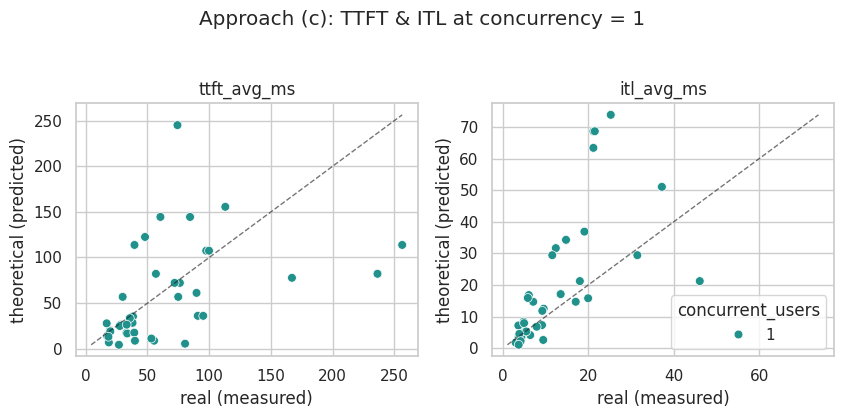

In [26]:
scatter_vs(err[err["concurrent_users"] == 1], ["ttft_avg_ms", "itl_avg_ms"],
           "Approach (c): TTFT & ITL at concurrency = 1")

---

**Fine Step 4.** Quantificato il residuo del modello calibrato: TTFT/ITL ~50% medAPE distribuito tra i modelli (in-sample), niente regimi patologici; throughput e power restano grandezze non confrontabili as-is. Margine residuo per l'ML: varianza per-modello e effetti di batching non catturati dalla struttura roofline.

## 5. Pipeline di Machine Learning

Obiettivo: imparare dai dati reali un modello che **corregga o batta** il teorico nel predire **TTFT, ITL e power_w**. Impostazione (decisa insieme):
- **Target** (scala log): `ttft_avg_ms`, `itl_avg_ms`, `power_w`.
- **Due framing**: **(A)** predizione da zero; **(B)** *residual* sul teorico (`log(reale/teorico)`, ricostruisce `reale = teorico x exp(pred)`).
- **Baseline da battere**: il valore del tool **roofline calibrato** (per `power_w`: `tdp x n_gpu`).
- **Validazione**: leave-one-model-out (6 fold) - test onesto sulla generalizzazione a modelli mai visti.
- **Feature**: fisiche (modello + GPU) + workload + termini del roofline calibrato. **Niente upsampling sintetico** (rischio di punti non-fisici e leakage).

> **Asimmetria dichiarata a favore della baseline**: i 4 parametri del roofline sono fittati *in-sample* su tutto il dataset, mentre l'ML e valutato *out-of-fold* (LOMO, il modello held-out non e mai visto in training ne in calibrazione). Se l'ML batte comunque la baseline, il risultato e conservativo.

Qui (5.1) costruiamo le feature; poi la harness LOMO (5.2) e i modelli A/B con i risultati (5.3).

### 5.1 Spec table e feature engineering

Congeliamo i parametri fisici dei 6 modelli (risolti dal tool stesso, quindi coerenti con la baseline teorica) e le specs delle 2 GPU **reali del benchmark** (H100 = profilo PCIe, H200 = SXM; TFLOPS dense). Da questi costruiamo le feature, inclusi i **termini del roofline calibrato** (`ttft_core`, `itl_mem_core`/`itl_compute_core`, `queue_factor`, `tp_eff`, risorse effettive aggregate, `kv_read_gb`, `vram_pressure`...). Le feature fisiche **sostituiscono l'encoding categorico** del modello: e cio che rende possibile il leave-one-model-out (un modello mai visto e solo un nuovo punto numerico). Il sanity check finale ricostruisce TTFT/ITL/power teorici dalle feature e li confronta col tool: se combaciano, la fisica e replicata correttamente.

In [27]:
# Physical specs FROZEN from the tool's own model resolution, so the features are
# consistent with the theoretical baseline. (gpt-oss is MoE: weights use total
# params, compute/bandwidth timings use ACTIVE params.)
N_IN, N_OUT = 512, 128

# PERF_MODEL constants of the CALIBRATED roofline model (fitted on this same
# benchmark with llm-sizing-tool/backend/calibrate_perf_model.py).
MFU, MBU = 0.413, 0.643               # effective FLOPs / bandwidth utilization
ETA = {"NVLink": 0.361, "PCIe": 0.372}  # TP scaling efficiency (1.0 when n_gpu == 1)
# NOTE (2026-06-11): parameters re-fitted on the 130 DENSE paired configs only.
# gpt-oss-120b (MoE) is excluded from the fit: with the model-card active params
# (5.1B, arXiv:2508.10925) the roofline underestimates it ~5x -> outside the
# closed-form validity domain (effective serving cost ~5x nominal active params).

MODEL_SPECS = {
    #                                params      active      is_moe layers hidden heads kv_heads
    "Llama-3.1-8B-Instruct":        dict(params=8.03e9,   active=8.03e9,   is_moe=0, layers=32, hidden=4096, heads=32, kv_heads=8),
    "Qwen2.5-7B-Instruct":          dict(params=7.616e9,  active=7.616e9,  is_moe=0, layers=28, hidden=3584, heads=28, kv_heads=4),
    "Qwen2.5-32B-Instruct":         dict(params=3.276e10, active=3.276e10, is_moe=0, layers=64, hidden=5120, heads=40, kv_heads=8),
    "DeepSeek-R1-Distill-Qwen-32B": dict(params=3.276e10, active=3.276e10, is_moe=0, layers=64, hidden=5120, heads=40, kv_heads=8),
    "Llama-3.3-70B-Instruct":       dict(params=7.055e10, active=7.055e10, is_moe=0, layers=80, hidden=8192, heads=64, kv_heads=8),
    # gpt-oss specs pinned from the model card (arXiv:2508.10925): 116.8B total, 5.1B active.
    # (Earlier: 120.4B/27.09B from HF safetensors + the 80%-experts heuristic of the tool.)
    "gpt-oss-120b":                 dict(params=1.168e11, active=5.1e9,    is_moe=1, layers=36, hidden=2880, heads=64, kv_heads=8),
}
# Dense-TFLOPS specs of the ACTUAL benchmark hardware: H100 = PCIe profile,
# H200 = SXM/NVLink (the same GPU profiles the tool uses).
GPU_SPECS_FE = {
    "H100": dict(mem_bw=2000, fp16_tflops=756, vram_gb=80,  tdp_w=350),
    "H200": dict(mem_bw=4800, fp16_tflops=989, vram_gb=141, tdp_w=700),
}
print("Model specs (frozen):")
display(pd.DataFrame(MODEL_SPECS).T)
print("GPU specs (frozen):")
display(pd.DataFrame(GPU_SPECS_FE).T)
print("Note: DeepSeek-R1-Distill-Qwen-32B and Qwen2.5-32B share identical specs "
      "(the distill is based on Qwen2.5-32B) -> indistinguishable in feature space.")

Model specs (frozen):


,params,active,is_moe,layers,hidden,heads,kv_heads
Llama-3.1-8B-Instruct,8.030000e+09,8.030000e+09,0.0,32.0,4096.0,32.0,8.0
Qwen2.5-7B-Instruct,7.616000e+09,7.616000e+09,0.0,28.0,3584.0,28.0,4.0
Qwen2.5-32B-Instruct,3.276000e+10,3.276000e+10,0.0,64.0,5120.0,40.0,8.0
DeepSeek-R1-Distill-Qwen-32B,3.276000e+10,3.276000e+10,0.0,64.0,5120.0,40.0,8.0
Llama-3.3-70B-Instruct,7.055000e+10,7.055000e+10,0.0,80.0,8192.0,64.0,8.0
gpt-oss-120b,1.168000e+11,5.100000e+09,1.0,36.0,2880.0,64.0,8.0


GPU specs (frozen):


,mem_bw,fp16_tflops,vram_gb,tdp_w
H100,2000,756,80,350
H200,4800,989,141,700


Note: DeepSeek-R1-Distill-Qwen-32B and Qwen2.5-32B share identical specs (the distill is based on Qwen2.5-32B) -> indistinguishable in feature space.


In [28]:
def build_features(df):
    """Add physics-based features replicating the CALIBRATED roofline model
    (gpu_calc.py + PERF_MODEL). Works on any df with columns
    model, gpu_arch, interconnect, n_gpu, concurrent_users."""
    df = df.copy()
    for k in ["params", "active", "is_moe", "layers", "hidden", "heads", "kv_heads"]:
        df[k if k != "active" else "active_params"] = df["model"].map(lambda m: MODEL_SPECS[m][k])
    for k in ["mem_bw", "fp16_tflops", "vram_gb", "tdp_w"]:
        df[k] = df["gpu_arch"].map(lambda g: GPU_SPECS_FE[g][k])
    df["nvlink"] = (df["interconnect"] == "NVLink").astype(int)
    df["params_per_layer"] = df["params"] / df["layers"]

    # Effective aggregate resources of the TP group (calibrated roofline)
    n, C = df["n_gpu"], df["concurrent_users"]
    df["tp_eff"]          = np.where(n == 1, 1.0, df["interconnect"].map(ETA))
    df["agg_tflops_eff"]  = n * df["fp16_tflops"] * MFU * df["tp_eff"]
    df["agg_bw_eff"]      = n * df["mem_bw"] * MBU * df["tp_eff"]
    df["queue_factor"]    = (C + 1) / 2                  # closed-loop TTFT queueing
    df["arith_intensity"] = df["fp16_tflops"] / df["mem_bw"]

    Pb_act, byt = df["active_params"] / 1e9, 2           # FP16 = 2 bytes/param
    df["ttft_core"] = (2 * Pb_act / df["agg_tflops_eff"]) * N_IN   # single-request prefill, ms

    # Decode roofline terms: weights read once per step + whole-batch KV at the
    # average generation context, vs batched compute. head_dim = hidden/heads.
    head_dim = df["hidden"] / df["heads"]
    df["kv_per_token_gb"]   = 2 * df["layers"] * df["kv_heads"] * head_dim * byt / 1e9
    df["kv_read_gb"]        = df["kv_per_token_gb"] * (N_IN + N_OUT / 2) * C
    df["weights_gb"]        = df["params"] * byt / 1e9   # resident (total params)
    df["weights_active_gb"] = Pb_act * byt               # read per decode step (active)
    df["itl_mem_core"]      = (df["weights_active_gb"] + df["kv_read_gb"]) / df["agg_bw_eff"] * 1000
    df["itl_compute_core"]  = (2 * Pb_act / df["agg_tflops_eff"]) * C
    df["vram_total_gb"]     = df["vram_gb"] * df["n_gpu"]
    df["vram_pressure"]     = (df["weights_gb"] + df["kv_per_token_gb"] * (N_IN + N_OUT) * C) / df["vram_total_gb"]
    return df

FEATURES = [
    "params", "active_params", "is_moe", "layers", "hidden", "heads", "kv_heads", "params_per_layer",
    "mem_bw", "fp16_tflops", "vram_gb", "tdp_w", "nvlink",
    "n_gpu", "concurrent_users", "queue_factor", "tp_eff",
    "agg_tflops_eff", "agg_bw_eff", "arith_intensity",
    "ttft_core", "itl_mem_core", "itl_compute_core",
    "kv_per_token_gb", "kv_read_gb", "weights_gb", "weights_active_gb", "vram_total_gb", "vram_pressure",
]
TARGETS = ["ttft_avg_ms", "itl_avg_ms", "power_w"]   # power_w: ML corrects the tdp*n nameplate
BIN_FEATURES = ["is_moe", "nvlink"]                            # pass through (binary)
LOG_FEATURES = [f for f in FEATURES if f not in BIN_FEATURES]  # strictly positive -> log-transform

feat = build_features(paired)
print(f"Feature matrix: {feat.shape[0]} configs x {len(FEATURES)} features  |  targets: {TARGETS}")
feat[["model", "gpu_arch", "n_gpu", "concurrent_users"] + FEATURES].head()

Feature matrix: 143 configs x 29 features  |  targets: ['ttft_avg_ms', 'itl_avg_ms', 'power_w']


,model,gpu_arch,n_gpu,concurrent_users,params,active_params,is_moe,layers,hidden,heads,kv_heads,params_per_layer,mem_bw,fp16_tflops,vram_gb,tdp_w,nvlink,n_gpu,concurrent_users,queue_factor,tp_eff,agg_tflops_eff,agg_bw_eff,arith_intensity,ttft_core,itl_mem_core,itl_compute_core,kv_per_token_gb,kv_read_gb,weights_gb,weights_active_gb,vram_total_gb,vram_pressure
0,DeepSeek-R1-Distill-Qwen-32B,H100,1,1,3.276000e+10,3.276000e+10,0,64,5120,40,8,511875000.0,2000,756,80,350,0,1,1,1.0,1.000,312.228000,1286.000,0.378,107.441485,51.066092,0.209847,0.000262,0.150995,65.52,65.52,80,0.821097
1,DeepSeek-R1-Distill-Qwen-32B,H100,2,1,3.276000e+10,3.276000e+10,0,64,5120,40,8,511875000.0,2000,756,80,350,0,2,1,1.0,0.372,232.297632,956.784,0.378,144.410598,68.637221,0.282052,0.000262,0.150995,65.52,65.52,160,0.410549
2,DeepSeek-R1-Distill-Qwen-32B,H100,2,10,3.276000e+10,3.276000e+10,0,64,5120,40,8,511875000.0,2000,756,80,350,0,2,10,5.5,0.372,232.297632,956.784,0.378,144.410598,70.057557,2.820519,0.000262,1.509949,65.52,65.52,160,0.419986
3,DeepSeek-R1-Distill-Qwen-32B,H100,2,50,3.276000e+10,3.276000e+10,0,64,5120,40,8,511875000.0,2000,756,80,350,0,2,50,25.5,0.372,232.297632,956.784,0.378,144.410598,76.370160,14.102597,0.000262,7.549747,65.52,65.52,160,0.461929
4,DeepSeek-R1-Distill-Qwen-32B,H100,2,100,3.276000e+10,3.276000e+10,0,64,5120,40,8,511875000.0,2000,756,80,350,0,2,100,50.5,0.372,232.297632,956.784,0.378,144.410598,84.260914,28.205195,0.000262,15.099494,65.52,65.52,160,0.514358


In [29]:
# Sanity check: rebuild the THEORETICAL TTFT/ITL/power from the engineered features
# and compare to the tool's output. We check the RELATIVE error (the meaningful one:
# TTFT spans ms..1e5 ms, so an absolute threshold would be misleading).
ttft_rebuilt  = feat["ttft_core"] * feat["queue_factor"]
itl_rebuilt   = np.maximum(feat["itl_mem_core"], feat["itl_compute_core"])
power_rebuilt = feat["tdp_w"] * feat["n_gpu"]
def max_rel_err(rebuilt, tool_val):
    return (np.abs(rebuilt - tool_val) / tool_val.abs()).max() * 100
rel = {
    "TTFT":  max_rel_err(ttft_rebuilt,  feat["ttft_avg_ms_theo"]),
    "ITL":   max_rel_err(itl_rebuilt,   feat["itl_avg_ms_theo"]),
    "power": max_rel_err(power_rebuilt,  feat["power_w_theo"]),
}
for k, v in rel.items():
    print(f"Max relative error  {k:6s}: {v:.4f} %")
print("=> physics features reproduce the theoretical model "
      "(<0.5% residuals = CSV 2-decimal rounding + the tool's seconds<->ms conversion)."
      if max(rel.values()) < 0.5 else "=> MISMATCH: check the feature formulas.")

Max relative error  TTFT  : 0.0638 %
Max relative error  ITL   : 0.2127 %
Max relative error  power : 0.0000 %
=> physics features reproduce the theoretical model (<0.5% residuals = CSV 2-decimal rounding + the tool's seconds<->ms conversion).


### 5.1b Analisi delle feature (correlazione, PCA, t-SNE)

Prima di modellare, guardiamo la struttura delle 29 feature.
- **Matrice di correlazione**: ci aspettiamo forte collinearita (params, active, weights, ttft_core... legate alla taglia del modello; e le spec GPU, che variano tra H100 PCIe e H200 ma restano perfettamente legate all'identita della GPU). Giustifica l'uso di Ridge e mostra che la dimensionalita effettiva e ben minore di 29.
- **PCA**: quante componenti bastano a spiegare la varianza, e la proiezione 2D mostra che i dati **si raggruppano per modello** -> ecco perche il leave-one-model-out e un'estrapolazione (si tiene fuori un intero cluster).
- **t-SNE**: complemento esplorativo per visualizzare i cluster (meno rigoroso della PCA su N=143).

In [30]:
from sklearn.preprocessing import StandardScaler

# Modeling space: log-transform positive features (binary ones left as-is).
const_feats = [c for c in FEATURES if feat[c].nunique() == 1]
nonconst    = [c for c in FEATURES if feat[c].nunique() >  1]
print("Constant (zero-variance) features in this dataset:", const_feats)
print(f"-> dead for prediction. {len(nonconst)} features actually vary.")

Xlog = feat[FEATURES].copy()
Xlog[LOG_FEATURES] = np.log(Xlog[LOG_FEATURES])
Xstd = StandardScaler().fit_transform(Xlog)   # standardized matrix reused by PCA / t-SNE

MODELS_LIST = sorted(feat["model"].unique())  # used by the colour-by-model plots and LOMO

Constant (zero-variance) features in this dataset: []
-> dead for prediction. 29 features actually vary.


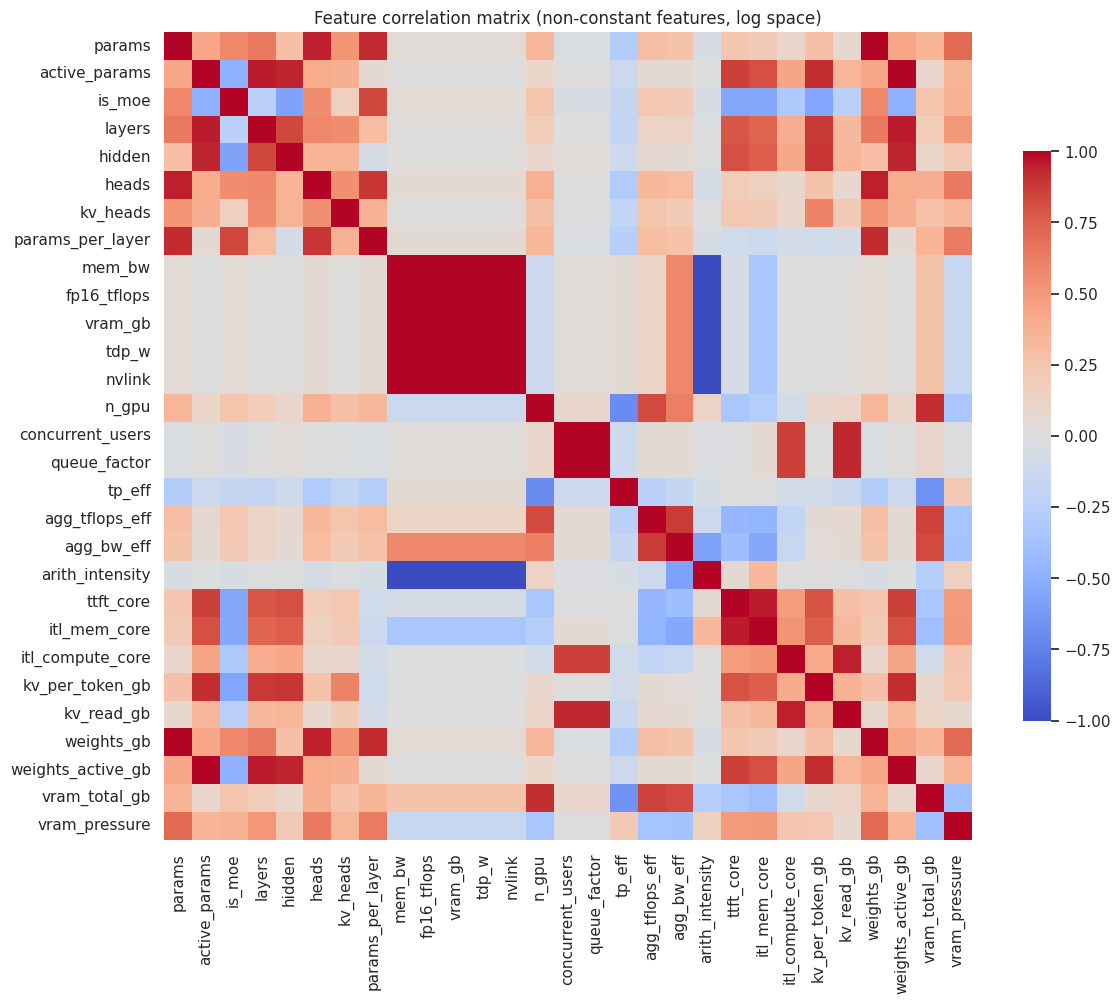

33 feature pairs with |r| > 0.9 (collinear) -> motivates Ridge / dim. reduction


In [31]:
# Correlation matrix (modeling space, non-constant features) -> multicollinearity.
corr = Xlog[nonconst].corr()
fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(corr, cmap="coolwarm", center=0, vmin=-1, vmax=1, square=True,
            cbar_kws={"shrink": 0.7}, ax=ax)
ax.set_title("Feature correlation matrix (non-constant features, log space)")
plt.tight_layout()
plt.show()

# Quick list of strongly collinear pairs (|r| > 0.9)
import itertools
strong = [(a, b, round(corr.loc[a, b], 2))
          for a, b in itertools.combinations(nonconst, 2) if abs(corr.loc[a, b]) > 0.9]
print(f"{len(strong)} feature pairs with |r| > 0.9 (collinear) -> motivates Ridge / dim. reduction")

Variance explained by PC1..PC5: [28.  24.6 18.  12.7 10.3] %
PCs needed for 95% variance: 6 of 29 features -> effective dimensionality is much smaller.


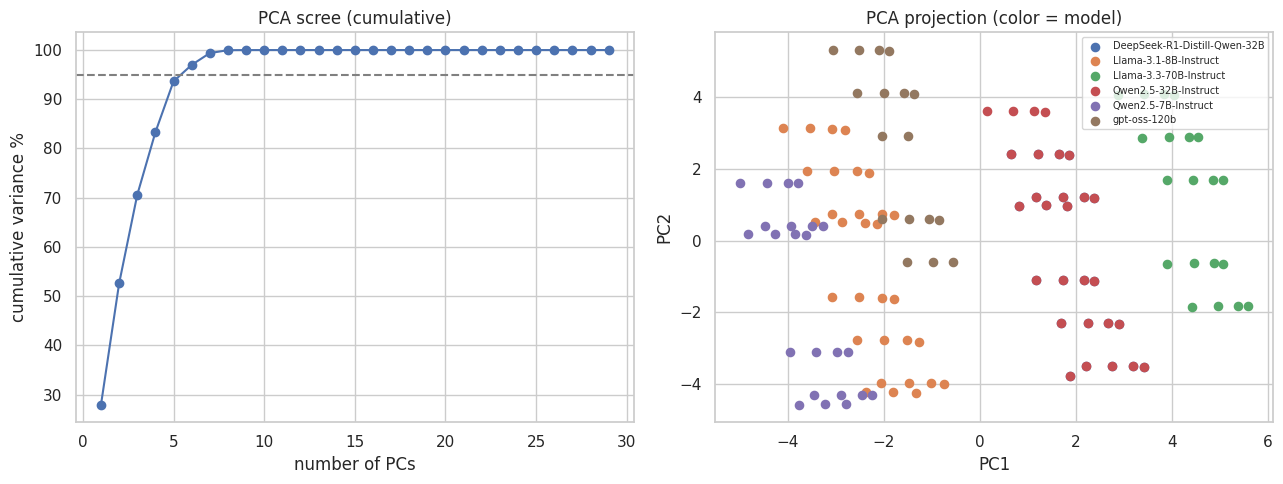

In [32]:
from sklearn.decomposition import PCA

pca = PCA().fit(Xstd)
evr = pca.explained_variance_ratio_
n95 = int(np.argmax(np.cumsum(evr) >= 0.95) + 1)
print(f"Variance explained by PC1..PC5: {(evr[:5] * 100).round(1)} %")
print(f"PCs needed for 95% variance: {n95} of {len(FEATURES)} features "
      f"-> effective dimensionality is much smaller.")

Z = pca.transform(Xstd)
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].plot(np.arange(1, len(evr) + 1), np.cumsum(evr) * 100, "o-")
axes[0].axhline(95, ls="--", c="grey")
axes[0].set(xlabel="number of PCs", ylabel="cumulative variance %", title="PCA scree (cumulative)")
for m in MODELS_LIST:
    idx = (feat["model"] == m).values
    axes[1].scatter(Z[idx, 0], Z[idx, 1], label=m, s=35)
axes[1].set(xlabel="PC1", ylabel="PC2", title="PCA projection (color = model)")
axes[1].legend(fontsize=7, loc="best")
plt.tight_layout()
plt.show()

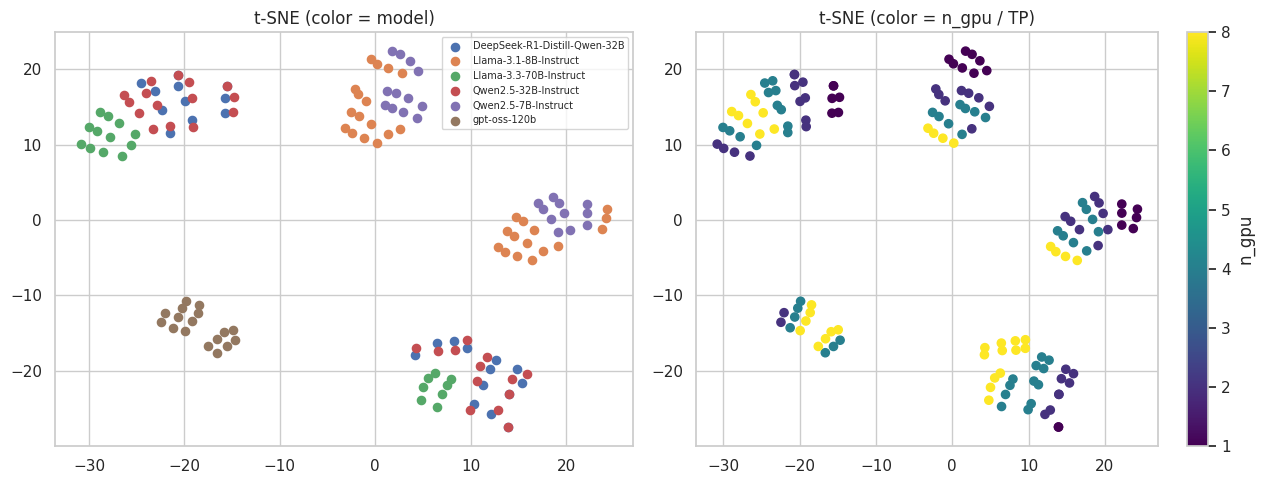

In [33]:
from sklearn.manifold import TSNE

Z2 = TSNE(n_components=2, perplexity=15, init="pca", random_state=0).fit_transform(Xstd)
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for m in MODELS_LIST:
    idx = (feat["model"] == m).values
    axes[0].scatter(Z2[idx, 0], Z2[idx, 1], label=m, s=35)
axes[0].set(title="t-SNE (color = model)")
axes[0].legend(fontsize=7, loc="best")
sc = axes[1].scatter(Z2[:, 0], Z2[:, 1], c=feat["n_gpu"], cmap="viridis", s=35)
axes[1].set(title="t-SNE (color = n_gpu / TP)")
plt.colorbar(sc, ax=axes[1], label="n_gpu")
plt.tight_layout()
plt.show()

---

**Fine Step 5.1.** Abbiamo le feature fisiche, la conferma che riproducono il modello teorico, e ne abbiamo capito la struttura (collinearita, dimensionalita effettiva, clustering per modello).

### 5.2 Harness di validazione (leave-one-model-out)

Valutiamo con **LOMO**: a turno teniamo fuori un intero modello, alleniamo sugli altri 5 e prediciamo sul modello mai visto. E' il test piu onesto di generalizzazione (e l'unico sensato qui, dato che le feature fisiche sostituiscono l'encoding del modello).

Dettagli della harness:
- **Pipeline per fold** (niente leakage): log-transform delle feature positive -> standardizzazione -> stimatore, tutto *fittato dentro il fold*.
- **Due framing**: **A** predice `log(reale)`; **B** predice `log(reale/teorico)` e ricostruisce `reale = teorico x exp(pred)`.
- **Baseline**: il valore teorico del tool, valutato sugli stessi fold.
- **Metriche**: MAPE e **mediana-APE** (robusta alle code lunghe viste nello Step 4).
- Stimatore di questo blocco: **Ridge** (lineare regolarizzato, estrapola bene). I modelli ad albero e il confronto finale sono nello Step 5.3.
- Le **predizioni per-fold** vengono salvate in `results/lomo_predictions.csv` per la tesi.

In [34]:
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler, FunctionTransformer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# BIN_FEATURES / LOG_FEATURES were defined in 5.1 (binary pass-through vs log-transform).
def make_pipeline(estimator):
    """log-transform positive features, standardize, then fit the estimator.
    All steps are fit INSIDE each fold (no leakage)."""
    pre = ColumnTransformer([
        ("log", FunctionTransformer(np.log, validate=False), LOG_FEATURES),
        ("bin", "passthrough", BIN_FEATURES),
    ])
    return Pipeline([("pre", pre), ("scale", StandardScaler()), ("est", estimator)])

In [35]:
def lomo_eval(estimator_factory, target, framing):
    """Leave-one-model-out. framing 'A' = predict log(real); 'B' = predict
    log(real/theoretical) and reconstruct real = theoretical * exp(pred).
    Returns one row per held-out config with real / theoretical / predicted."""
    rows = []
    for held in MODELS_LIST:
        tr = feat[feat["model"] != held]
        te = feat[feat["model"] == held]
        if len(te) == 0:
            continue
        real_tr, theo_tr = tr[f"{target}_real"], tr[f"{target}_theo"]
        real_te, theo_te = te[f"{target}_real"].values, te[f"{target}_theo"].values
        y_tr = np.log(real_tr) if framing == "A" else np.log(real_tr / theo_tr)

        pipe = estimator_factory()
        pipe.fit(tr[FEATURES], y_tr)
        pred = pipe.predict(te[FEATURES])
        pred_real = np.exp(pred) if framing == "A" else theo_te * np.exp(pred)

        sub = te[["model", "gpu_arch", "interconnect", "n_gpu", "concurrent_users"]].copy()
        sub.insert(0, "framing", framing); sub.insert(0, "target", target)
        sub["y_real"], sub["y_theo"], sub["y_pred"] = real_te, theo_te, pred_real
        rows.append(sub)
    out = pd.concat(rows, ignore_index=True)
    out["ape_pred"] = (out["y_pred"] - out["y_real"]).abs() / out["y_real"] * 100
    out["ape_theo"] = (out["y_theo"] - out["y_real"]).abs() / out["y_real"] * 100
    return out

In [36]:
# Run the harness with Ridge for the 3 targets x 2 framings, and SAVE per-fold predictions.
import os
ridge_factory = lambda: make_pipeline(Ridge(alpha=1.0))
preds = pd.concat([lomo_eval(ridge_factory, t, fr) for t in TARGETS for fr in ["A", "B"]],
                  ignore_index=True)

os.makedirs("results", exist_ok=True)
preds.to_csv("results/lomo_predictions.csv", index=False)
print(f"Saved {len(preds)} per-fold predictions -> results/lomo_predictions.csv\n")

summary = (preds.groupby(["target", "framing"])
           .agg(MAPE_pred=("ape_pred", "mean"),  medAPE_pred=("ape_pred", "median"),
                MAPE_theo=("ape_theo", "mean"),  medAPE_theo=("ape_theo", "median"),
                n=("ape_pred", "size")).round(1))
print("LOMO error: ML (Ridge) vs theoretical baseline  [lower is better]")
summary

Saved 858 per-fold predictions -> results/lomo_predictions.csv

LOMO error: ML (Ridge) vs theoretical baseline  [lower is better]


MAPE_pred  medAPE_pred  MAPE_theo  medAPE_theo    n
target      framing                                                     
itl_avg_ms  A             54.5         47.3       60.0         51.3  143
            B             45.5         38.9       60.0         51.3  143
power_w     A              2.4          2.2      186.5        167.8  143
            B              2.5          2.0      186.5        167.8  143
ttft_avg_ms A             70.6         53.2       75.3         55.4  143
            B             68.5         57.0       75.3         55.4  143

---

**Fine Step 5.2.** Harness LOMO pronta, predizioni per-fold salvate, primo confronto Ridge vs baseline.

### 5.3 Confronto modelli e risultati finali

Confrontiamo **Ridge** (lineare regolarizzato), **Gradient Boosting** e **Random Forest** sui 3 target x 2 framing (A/B), sempre in leave-one-model-out. Poi scegliamo la configurazione migliore per target (per **median-APE**, robusta alle code), guardiamo il **breakdown per modello** e produciamo i grafici finali.

> *Caveat dichiarato:* gli alberi (GBM/RF) **non estrapolano** oltre il range visto in training; nel LOMO, sul modello held-out piu grande o piu piccolo possono andare peggio di Ridge. Niente nested-CV (dataset piccolo): iperparametri ragionevoli fissi.

In [37]:
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor

# Trees are invariant to the monotone log+scale transforms, so the same pipeline is fine.
ESTIMATORS = {
    "Ridge": lambda: make_pipeline(Ridge(alpha=1.0)),
    "GBM":   lambda: make_pipeline(GradientBoostingRegressor(
                 n_estimators=300, max_depth=2, learning_rate=0.05, random_state=0)),
    "RF":    lambda: make_pipeline(RandomForestRegressor(
                 n_estimators=400, min_samples_leaf=2, random_state=0, n_jobs=-1)),
}

all_preds = {}
for name, fac in ESTIMATORS.items():
    p = pd.concat([lomo_eval(fac, t, fr) for t in TARGETS for fr in ["A", "B"]], ignore_index=True)
    p["estimator"] = name
    all_preds[name] = p
comp = pd.concat(all_preds.values(), ignore_index=True)

baseline = (comp.drop_duplicates(["target", "model", "gpu_arch", "interconnect", "n_gpu", "concurrent_users"])
            .groupby("target").agg(MAPE_theo=("ape_theo", "mean"),
                                   medAPE_theo=("ape_theo", "median")).round(1))
table = (comp.groupby(["target", "estimator", "framing"])
         .agg(MAPE=("ape_pred", "mean"), medAPE=("ape_pred", "median")).round(1))
print("Theoretical baseline (per target):")
display(baseline)
print("ML models, LOMO  [MAPE / median-APE, %]:")
table

Theoretical baseline (per target):


,MAPE_theo,medAPE_theo
target,,
itl_avg_ms,60.0,51.3
power_w,186.5,167.8
ttft_avg_ms,75.3,55.4


ML models, LOMO  [MAPE / median-APE, %]:


MAPE  medAPE
target      estimator framing              
itl_avg_ms  GBM       A        48.1    33.0
                      B        53.4    29.2
            RF        A        44.8    33.3
                      B        56.9    34.2
            Ridge     A        54.5    47.3
                      B        45.5    38.9
power_w     GBM       A         1.2     1.0
                      B         1.2     1.0
            RF        A         1.2     0.9
                      B         1.2     0.9
            Ridge     A         2.4     2.2
                      B         2.5     2.0
ttft_avg_ms GBM       A        65.6    44.3
                      B        79.4    44.1
            RF        A        60.2    45.0
                      B        78.1    39.6
            Ridge     A        70.6    53.2
                      B        68.5    57.0

In [38]:
# Best (estimator, framing) per target by median-APE, then per-model breakdown.
best_keys = {}
for t in TARGETS:
    sub = comp[comp["target"] == t]
    g = sub.groupby(["estimator", "framing"])["ape_pred"].median()
    name, fr = g.idxmin()
    best_keys[t] = (name, fr)
    print(f"{t:14s} best: {name:5s}-{fr}  medAPE {g.min():5.1f}%   (baseline {sub['ape_theo'].median():.1f}%)")

best = pd.concat([comp[(comp.target == t) & (comp.estimator == nm) & (comp.framing == fr)]
                  for t, (nm, fr) in best_keys.items()], ignore_index=True)
print("\nPer-model breakdown (best config per target):")
pm = best.groupby(["target", "model"]).agg(
        medAPE_ml=("ape_pred", "median"), MAPE_ml=("ape_pred", "mean"),
        medAPE_theo=("ape_theo", "median")).round(1)
pm

ttft_avg_ms    best: RF   -B  medAPE  39.6%   (baseline 55.4%)
itl_avg_ms     best: GBM  -B  medAPE  29.2%   (baseline 51.3%)
power_w        best: RF   -A  medAPE   0.9%   (baseline 167.8%)

Per-model breakdown (best config per target):


medAPE_ml  MAPE_ml  medAPE_theo
target      model                                                        
itl_avg_ms  DeepSeek-R1-Distill-Qwen-32B       28.8     62.1         46.1
            Llama-3.1-8B-Instruct              20.8     55.7         36.5
            Llama-3.3-70B-Instruct             50.5     80.6         69.2
            Qwen2.5-32B-Instruct               20.2     46.4         57.0
            Qwen2.5-7B-Instruct                13.9     20.3         33.3
            gpt-oss-120b                       65.0     61.5         82.5
power_w     DeepSeek-R1-Distill-Qwen-32B        1.4      1.5        129.1
            Llama-3.1-8B-Instruct               0.5      1.1        167.5
            Llama-3.3-70B-Instruct              0.9      1.2        244.3
            Qwen2.5-32B-Instruct                1.0      1.2        168.1
            Qwen2.5-7B-Instruct                 0.6      1.4         87.4
            gpt-oss-120b                        0.8      1.2        242.5
ttft_avg_ms DeepSeek-R1-Distill-Qwen-32B       75.2     87.5         57.4
            Llama-3.1-8B-Instruct              33.2    109.4         47.6
            Llama-3.3-70B-Instruct             31.0     95.4         63.2
            Qwen2.5-32B-Instruct               30.7     65.6         53.8
            Qwen2.5-7B-Instruct                27.1     29.2         42.2
            gpt-oss-120b                       76.7     73.9         89.7

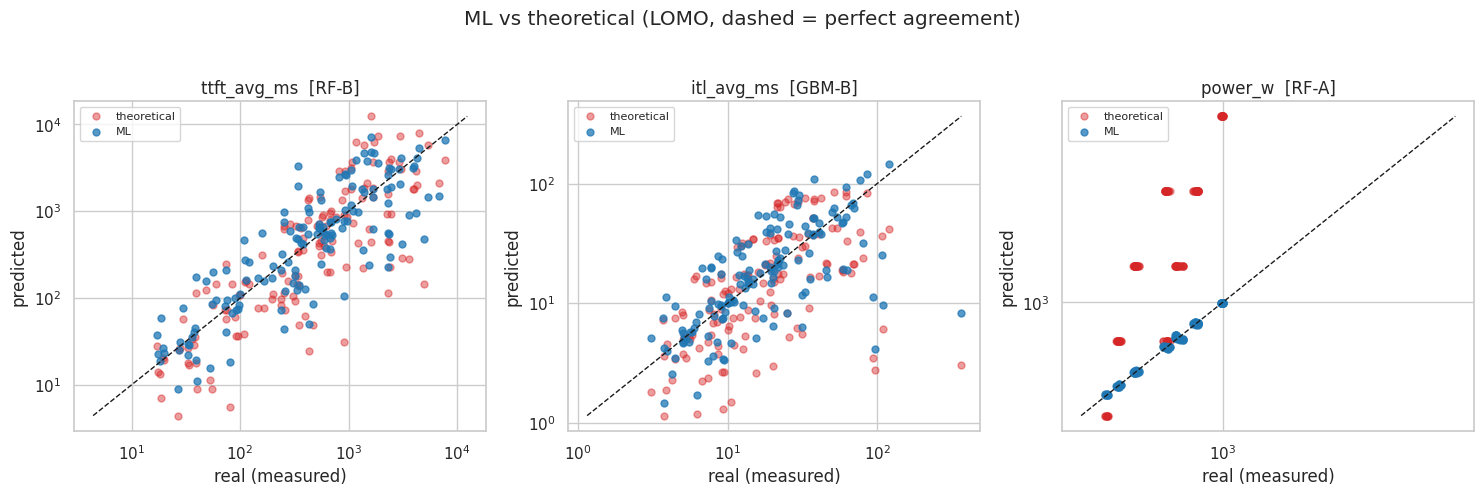

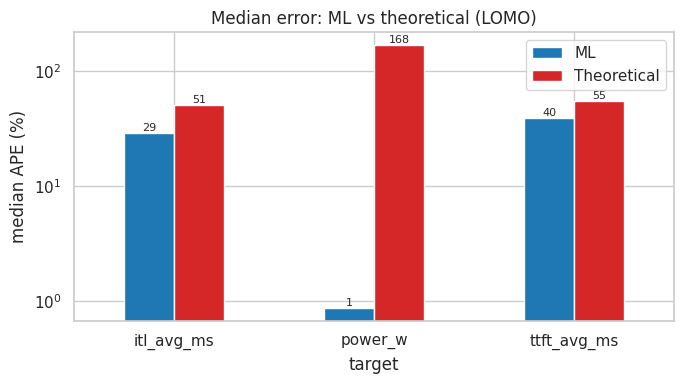

In [39]:
# Predicted vs real (ML and theoretical), log-log, one panel per target.
fig, axes = plt.subplots(1, 3, figsize=(15, 4.8))
for ax, t in zip(axes, TARGETS):
    s = best[best.target == t]
    ax.scatter(s.y_real, s.y_theo, s=25, alpha=0.45, color="tab:red",  label="theoretical")
    ax.scatter(s.y_real, s.y_pred, s=25, alpha=0.75, color="tab:blue", label="ML")
    lo = max(min(s.y_real.min(), s.y_pred.min(), s.y_theo.min()), 1e-2)
    hi = max(s.y_real.max(), s.y_pred.max(), s.y_theo.max())
    ax.plot([lo, hi], [lo, hi], "k--", lw=1)
    ax.set(xscale="log", yscale="log", xlabel="real (measured)", ylabel="predicted",
           title=f"{t}  [{best_keys[t][0]}-{best_keys[t][1]}]")
    ax.legend(fontsize=8)
fig.suptitle("ML vs theoretical (LOMO, dashed = perfect agreement)", y=1.03)
plt.tight_layout()
plt.show()

# Median APE: ML vs baseline per target (log y, ML is tiny for power).
agg = best.groupby("target").agg(ML=("ape_pred", "median"), Theoretical=("ape_theo", "median"))
ax = agg.plot(kind="bar", figsize=(7, 4), color=["tab:blue", "tab:red"])
ax.set(ylabel="median APE (%)", title="Median error: ML vs theoretical (LOMO)", yscale="log")
for c in ax.containers:
    ax.bar_label(c, fmt="%.0f", fontsize=8)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [40]:
# Save all artifacts for the thesis.
comp.to_csv("results/lomo_predictions_all_estimators.csv", index=False)
table.to_csv("results/lomo_model_comparison.csv")
pm.to_csv("results/lomo_per_model.csv")
print("Saved -> results/: lomo_predictions_all_estimators.csv, lomo_model_comparison.csv, lomo_per_model.csv")

Saved -> results/: lomo_predictions_all_estimators.csv, lomo_model_comparison.csv, lomo_per_model.csv


**Lettura dei risultati (baseline = roofline calibrato).** `power_w` resta il caso piu netto: l'ML scende sotto l'1% di errore mediano contro ~168% della targa `tdp x n`, imparando la curva di utilizzo per-GPU. Su `TTFT` il best e RF-B (medAPE ~40% vs ~55% della baseline) e su `ITL` GBM-B (~29% vs ~51%): guadagni di **1.4-1.8x** su una baseline fisica gia solida. L'ML pero **non vince su ogni fold**: sul TTFT di `DeepSeek-R1-Distill` la baseline calibrata fa meglio (75 vs 57 medAPE) - le feature fisiche non distinguono i *gemelli architetturali* (specs identiche a Qwen2.5-32B, comportamento reale diverso) - onesto dichiararlo, insieme al fatto che la baseline e fittata in-sample (vedi 5. intro) quindi il confronto e *conservativo* per l'ML. Il framing **B (residual)** vince quasi ovunque sui target di latenza, segno che la baseline e ormai informativa; **A** vince su power, dove il teorico e fuori scala. Tutti gli artefatti sono in `results/` per tabelle e figure della tesi.

---

**Fine Step 5.** Pipeline ML completa: feature fisiche, validazione LOMO onesta, confronto modelli e baseline, artefatti salvati.

## 6. Sintesi per la tesi

Impacchettiamo i risultati: una **tabella riassuntiva** 'da paper' (ML vs teorico per target), l'**esportazione delle figure chiave** in `results/figures/` (PNG ad alta risoluzione, pronte da inserire in tesi/white paper), e una nota su **limiti e lavoro futuro**.

In [41]:
# Paper-ready summary: best ML config vs theoretical baseline, per target.
summary_rows = []
for t in TARGETS:
    nm, fr = best_keys[t]
    s = best[best.target == t]
    summary_rows.append({
        "target": t, "best_ML": f"{nm}-{fr}",
        "medAPE_ML": s["ape_pred"].median(), "medAPE_theo": s["ape_theo"].median(),
        "MAPE_ML": s["ape_pred"].mean(), "MAPE_theo": s["ape_theo"].mean(),
        "improvement_x": s["ape_theo"].median() / s["ape_pred"].median(),
    })
summary_table = pd.DataFrame(summary_rows).set_index("target").round(1)
summary_table.to_csv("results/summary_table.csv")
print("HEADLINE - ML vs theoretical (LOMO, median-APE), saved to results/summary_table.csv")
summary_table

HEADLINE - ML vs theoretical (LOMO, median-APE), saved to results/summary_table.csv


,best_ML,medAPE_ML,medAPE_theo,MAPE_ML,MAPE_theo,improvement_x
target,,,,,,
ttft_avg_ms,RF-B,39.6,55.4,78.1,75.3,1.4
itl_avg_ms,GBM-B,29.2,51.3,53.4,60.0,1.8
power_w,RF-A,0.9,167.8,1.2,186.5,191.7


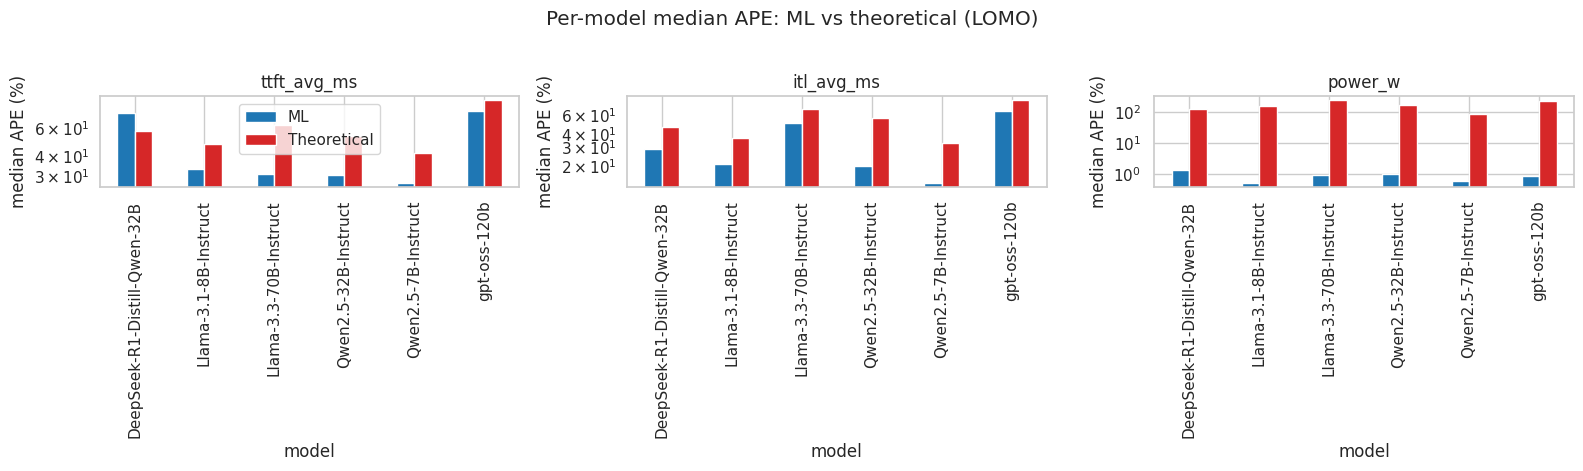

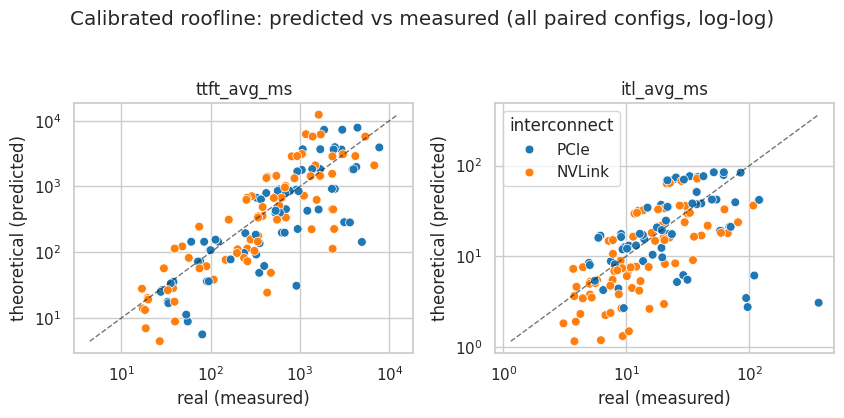

Saved figures -> results/figures/: ['energy_per_mtok.png', 'median_ape_bars.png', 'ml_vs_theoretical_scatter.png', 'per_model_ape.png', 'pred_vs_real_ttft_itl.png']


In [42]:
# Export the key figures as high-resolution PNG for the thesis / white paper.
import os
os.makedirs("results/figures", exist_ok=True)
DPI = 150

# Fig 1: predicted vs real (ML and theoretical), log-log
fig, axes = plt.subplots(1, 3, figsize=(15, 4.8))
for ax, t in zip(axes, TARGETS):
    s = best[best.target == t]
    ax.scatter(s.y_real, s.y_theo, s=25, alpha=0.45, color="tab:red",  label="theoretical")
    ax.scatter(s.y_real, s.y_pred, s=25, alpha=0.75, color="tab:blue", label="ML")
    lo = max(min(s.y_real.min(), s.y_pred.min(), s.y_theo.min()), 1e-2)
    hi = max(s.y_real.max(), s.y_pred.max(), s.y_theo.max())
    ax.plot([lo, hi], [lo, hi], "k--", lw=1)
    ax.set(xscale="log", yscale="log", xlabel="real (measured)", ylabel="predicted",
           title=f"{t} [{best_keys[t][0]}-{best_keys[t][1]}]")
    ax.legend(fontsize=8)
fig.suptitle("ML vs theoretical (LOMO, dashed = perfect agreement)", y=1.03)
fig.tight_layout()
fig.savefig("results/figures/ml_vs_theoretical_scatter.png", dpi=DPI, bbox_inches="tight")
plt.close(fig)

# Fig 2: median APE bars, ML vs baseline
agg = best.groupby("target").agg(ML=("ape_pred", "median"), Theoretical=("ape_theo", "median"))
fig, ax = plt.subplots(figsize=(7, 4))
agg.plot(kind="bar", ax=ax, color=["tab:blue", "tab:red"])
ax.set(ylabel="median APE (%)", yscale="log", title="Median error: ML vs theoretical (LOMO)")
for c in ax.containers:
    ax.bar_label(c, fmt="%.0f", fontsize=8)
plt.xticks(rotation=0)
fig.tight_layout()
fig.savefig("results/figures/median_ape_bars.png", dpi=DPI, bbox_inches="tight")
plt.close(fig)

# Fig 3: per-model median APE (ML vs theoretical), shown inline too
pm2 = best.groupby(["target", "model"]).agg(
        ML=("ape_pred", "median"), Theoretical=("ape_theo", "median")).reset_index()
fig, axes = plt.subplots(1, 3, figsize=(16, 4.6))
for ax, t in zip(axes, TARGETS):
    d = pm2[pm2.target == t].set_index("model")[["ML", "Theoretical"]]
    d.plot(kind="bar", ax=ax, color=["tab:blue", "tab:red"], legend=(ax is axes[0]))
    ax.set(title=t, ylabel="median APE (%)", yscale="log")
    ax.tick_params(axis="x", rotation=90)
fig.suptitle("Per-model median APE: ML vs theoretical (LOMO)", y=1.02)
fig.tight_layout()
fig.savefig("results/figures/per_model_ape.png", dpi=DPI, bbox_inches="tight")
plt.show()

# Fig 4 (thesis F8/F9): predicted vs measured TTFT & ITL, all paired configs, log-log
scatter_vs(err, ["ttft_avg_ms", "itl_avg_ms"],
           "Calibrated roofline: predicted vs measured (all paired configs, log-log)",
           hue="interconnect", log=True,
           savepath="results/figures/pred_vs_real_ttft_itl.png")

print("Saved figures -> results/figures/:", sorted(os.listdir("results/figures")))

### 6.0 Energia per token (kWh/Mtok)

Convertiamo le misure di potenza in **energia per token**: `E = power_w / throughput_aggregato` (J/token), riportata come **kWh per 1M token** di output (numericamente identica a Wh per 1k token). Due note metodologiche: (1) la formula per-richiesta `power x latenza / token` conterebbe la potenza di sistema una volta per ogni richiesta in volo -> sovrastima di ~C a concurrency C; si usa il throughput aggregato. (2) per la stima a targa usiamo `TDP x n_gpu` diviso per lo **stesso** throughput misurato: cosi il confronto isola l'errore sulla potenza, senza mescolarlo con quello sul throughput. Messaggi attesi: l'energia per token **cala di ~20x con la concurrency** (il batching ammortizza una potenza quasi costante) e la stima a targa **sovrastima di ~2.6x** (mediana).

median kWh per 1M output tokens (measured power vs TDP nameplate):


kwh_per_mtok             kwh_per_mtok_tdp            
gpu                 H100 PCIe H200 NVLink        H100 PCIe H200 NVLink
concurrent_users                                                      
1                       2.204       1.695            4.198       5.000
10                      0.385       0.264            0.670       0.732
50                      0.142       0.152            0.277       0.318
100                     0.118       0.083            0.272       0.203

median nameplate/measured ratio: 2.64x | overall median measured: 0.278 kWh/Mtok


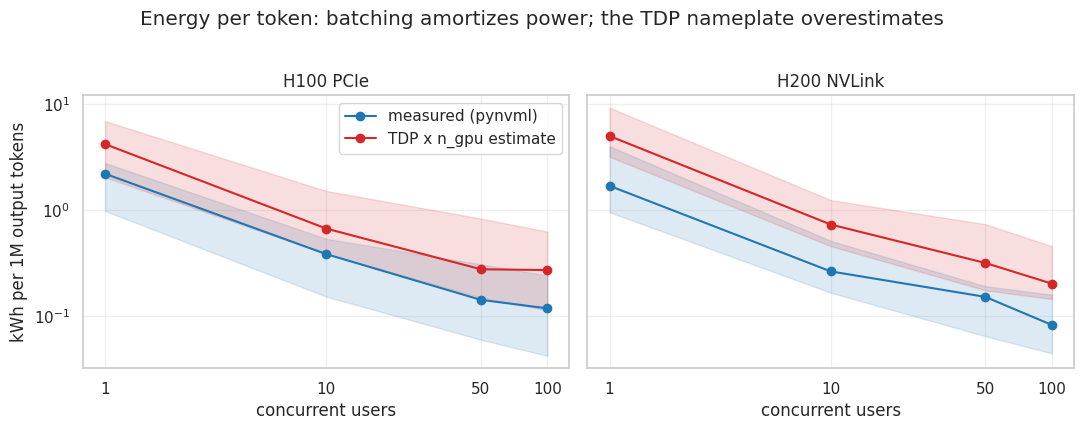

In [43]:
# Energy per token (thesis Part III): rate = power / AGGREGATE throughput.
# NOTE: the per-request formula power*latency/tokens would count the system
# power once per in-flight request -> overestimates by ~C at concurrency C.
en = bench_k[bench_k.output_token_throughput > 0].copy()
en["gpu"] = np.where(en.gpu_arch == "H100", "H100 PCIe", "H200 NVLink")
J_PER_KWH = 3.6e6
en["kwh_per_mtok"]     = en.power_w / en.output_token_throughput * 1e6 / J_PER_KWH
en["tdp_power_w"]      = en.gpu_arch.map(lambda a: GPU_SPECS_FE[a]["tdp_w"]) * en.n_gpu
en["kwh_per_mtok_tdp"] = en.tdp_power_w / en.output_token_throughput * 1e6 / J_PER_KWH

piv = en.pivot_table(values=["kwh_per_mtok", "kwh_per_mtok_tdp"],
                     index="concurrent_users", columns="gpu", aggfunc="median").round(3)
print("median kWh per 1M output tokens (measured power vs TDP nameplate):")
display(piv)
ratio = (en.kwh_per_mtok_tdp / en.kwh_per_mtok).median()
print(f"median nameplate/measured ratio: {ratio:.2f}x | "
      f"overall median measured: {en.kwh_per_mtok.median():.3f} kWh/Mtok")

(en.groupby(["gpu", "n_gpu", "concurrent_users"])[["kwh_per_mtok", "kwh_per_mtok_tdp"]]
   .median().round(4).to_csv("results/energy_per_mtok.csv"))

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2), sharey=True)
for ax, gpu in zip(axes, ["H100 PCIe", "H200 NVLink"]):
    d = en[en.gpu == gpu]
    for col, color, label in [("kwh_per_mtok", "tab:blue", "measured (pynvml)"),
                              ("kwh_per_mtok_tdp", "tab:red", "TDP x n_gpu estimate")]:
        g = d.groupby("concurrent_users")[col]
        ax.plot(g.median().index, g.median().values, "o-", color=color, label=label)
        ax.fill_between(g.median().index, g.quantile(.25), g.quantile(.75),
                        color=color, alpha=0.15)
    ax.set(xscale="log", yscale="log", title=gpu, xlabel="concurrent users")
    ax.set_xticks([1, 10, 50, 100]); ax.set_xticklabels([1, 10, 50, 100])
    ax.grid(alpha=0.3)
axes[0].set_ylabel("kWh per 1M output tokens")
axes[0].legend()
fig.suptitle("Energy per token: batching amortizes power; the TDP nameplate overestimates", y=1.02)
fig.tight_layout()
fig.savefig("results/figures/energy_per_mtok.png", dpi=DPI, bbox_inches="tight")
plt.show()

### 6.1 Limiti e lavoro futuro

**Limiti (da dichiarare in tesi):**
- **N piccolo**: 143 configurazioni appaiate, 6 modelli. Il leave-one-model-out e severo e le stime hanno varianza non trascurabile -> risultati *indicativi*, non definitivi.
- **Baseline calibrata in-sample**: i 4 parametri del roofline sono fittati su questo stesso dataset, mentre l'ML e out-of-fold -> il confronto e conservativo per l'ML, ma gli errori "teorici" dello Step 4 non misurano la generalizzazione del tool a hardware/workload nuovi.
- **Input/output fissi** (512->128): nessuna generalizzazione su lunghezze di sequenza diverse; il carico varia solo tramite la concurrency.
- **Collinearita GPU/interconnessione**: nei dati H100 e sempre PCIe e H200 sempre NVLink, quindi l'effetto dell'architettura e dell'interconnessione non e separabile (le spec GPU variano, ma in blocco con l'identita della GPU).
- **Un solo MoE** (gpt-oss): la generalizzazione ai MoE non e davvero testabile. Con le spec della model card (116.8B totali / 5.1B attivi, arXiv:2508.10925) il roofline lo sottostima ~5x -> e **escluso dal fit di calibrazione** (fuori dominio): il costo effettivo di serving di un MoE sparso e molto sopra i parametri attivi nominali (kernel grouped-GEMM, traffico pesi per-batch; il vecchio valore euristico di 27.09B attivi era di fatto un buon 'costo effettivo'). Resta il fold piu debole per l'ML sui target di latenza. Inoltre gpt-oss reale gira quantizzato (MXFP4) mentre il tool lo modella FP16.
- **Baseline teorica** = il modello roofline calibrato del tool; le conclusioni sono legate a quella implementazione. `power_w` reale e una misura puntuale (sensibile a temperatura/throttling).

**Lavoro futuro:**
- Piu benchmark reali (altre GPU, piu MoE, interconnessioni miste) per ampliare N e rompere le collinearita.
- Variare le lunghezze input/output per testare la generalizzazione.
- Termine di contention del decode nel modello fisico (il fit esteso indica che la lettura KV del batch pesa ~4x il termine teorico puro).
- Calibrazione per-fold (rifittare i 4 parametri dentro ogni fold LOMO) per un confronto fisico-vs-ML del tutto simmetrico.
- Stima dell'incertezza sulle predizioni (intervalli di confidenza).

---

**Notebook completo.** Panoramica dati, confronto reale-vs-teorico, e pipeline ML (feature fisiche, LOMO, modelli A/B) con artefatti e figure pronti per la stesura della tesi in `results/`.

## 7 · Errore vs numero di GPU (TP) a concurrency fissa

Domanda: *dove* si concentra l'errore del modello fisico al crescere del parallelismo, e il correttivo ML lo assorbe? A concurrency fissa (C=1, il regime più pulito: niente coda) confrontiamo il medAPE della predizione teorica e di quella ML (miglior stimatore per target, predizioni out-of-fold LOMO) per livello di tensor parallelism. Nota chiave: a TP=1 non c'è comunicazione inter-GPU (η=1), quindi l'errore residuo lì misura la pura qualità di MFU/MBU; da TP≥2 entra in gioco il termine η.

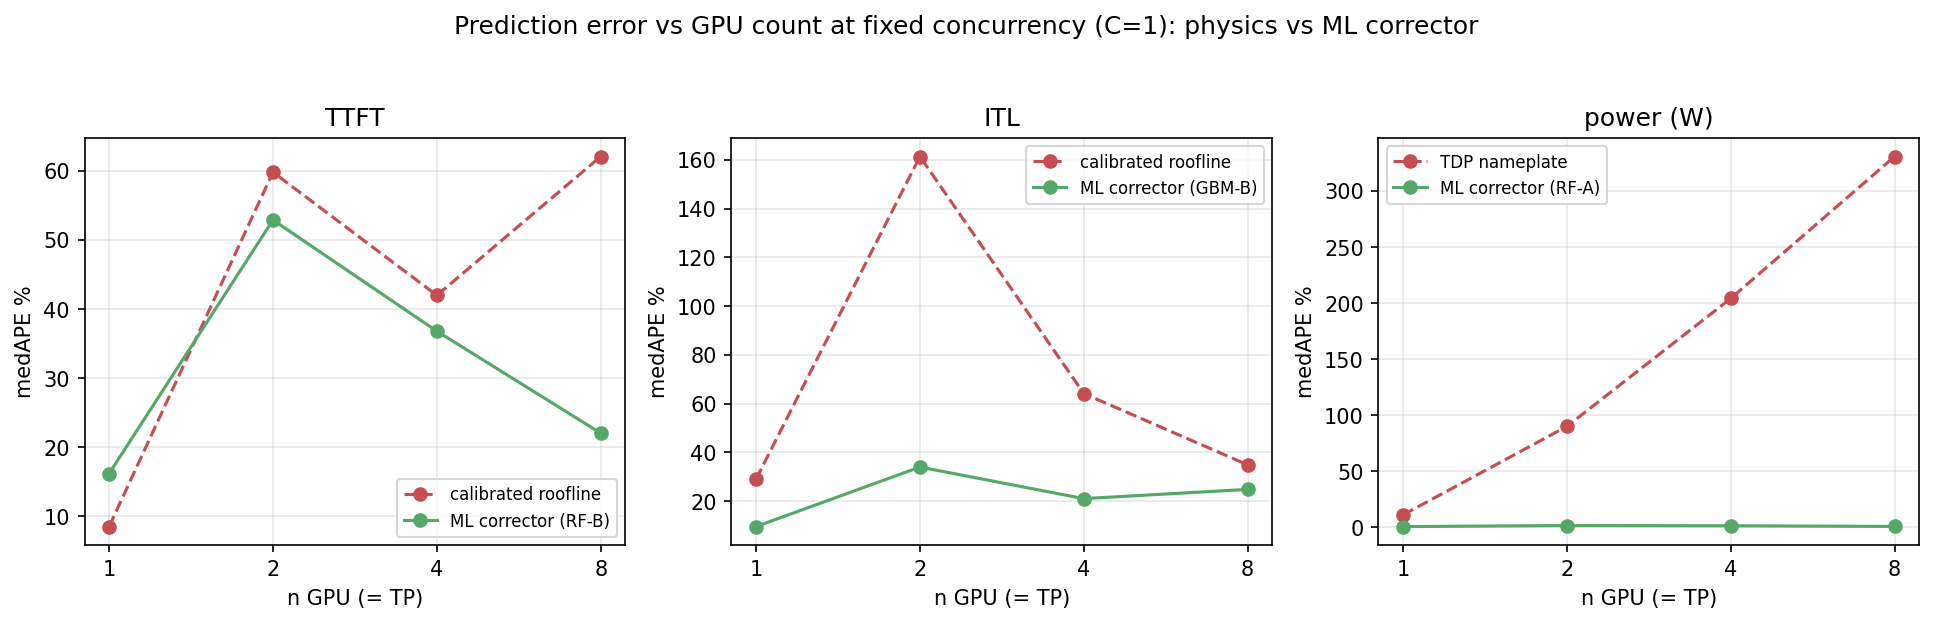

     target  n_gpu  n_config  medAPE_theo  medAPE_ml
ttft_avg_ms      1         8          8.5       16.2
ttft_avg_ms      2        10         59.8       52.9
ttft_avg_ms      4        12         42.0       36.8
ttft_avg_ms      8         9         62.1       22.0
 itl_avg_ms      1         8         29.0        9.6
 itl_avg_ms      2        10        161.4       34.0
 itl_avg_ms      4        12         64.1       21.0
 itl_avg_ms      8         9         34.9       24.8
    power_w      1         8         11.2        0.7
    power_w      2        10         90.0        1.6
    power_w      4        12        204.1        1.4
    power_w      8         9        330.7        0.9
TTFT @ C=10: TP1: roofline 53% vs ML 68% | TP2: roofline 54% vs ML 55% | TP4: roofline 65% vs ML 49% | TP8: roofline 68% vs ML 28%
TTFT @ C=50: TP1: roofline 55% vs ML 62% | TP2: roofline 118% vs ML 77% | TP4: roofline 35% vs ML 37% | TP8: roofline 60% vs ML 23%
TTFT @ C=100: TP1: roofline 45% vs ML 11% | TP2:

In [44]:
# Section 7 - Error vs GPU count (TP) at fixed concurrency.
# Where does the physical model's error concentrate as parallelism grows,
# and does the ML corrector absorb it? Per-config LOMO predictions,
# best estimator per target (Step 5.3). TP=1 has no inter-GPU communication
# (eta=1): the residual error there measures pure MFU/MBU quality.
try:
    ep = comp.copy()                     # in-memory from Step 5.3
except NameError:
    ep = pd.read_csv("results/lomo_predictions_all_estimators.csv")

BEST_TP = {"ttft_avg_ms": ("RF", "B"), "itl_avg_ms": ("GBM", "B"), "power_w": ("RF", "A")}
C_FIX = 1

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
rows = []
for ax, (tgt, (est, fr)) in zip(axes, BEST_TP.items()):
    sub = ep[(ep.target == tgt) & (ep.estimator == est) & (ep.framing == fr)
             & (ep.concurrent_users == C_FIX)]
    g = sub.groupby("n_gpu").agg(n=("ape_theo", "size"),
                                 theo=("ape_theo", "median"),
                                 ml=("ape_pred", "median"))
    x = g.index.astype(str)
    lbl = "TDP nameplate" if tgt == "power_w" else "calibrated roofline"
    ax.plot(x, g.theo, "o--", color="#C44E52", label=lbl)
    ax.plot(x, g.ml, "o-", color="#55A868", label=f"ML corrector ({est}-{fr})")
    ax.set(title=tgt.replace("_avg_ms", "").upper().replace("POWER_W", "power (W)"),
           xlabel="n GPU (= TP)", ylabel="medAPE %")
    ax.grid(alpha=0.3); ax.legend(fontsize=8)
    for tp, r in g.iterrows():
        rows.append({"target": tgt, "n_gpu": int(tp), "n_config": int(r.n),
                     "medAPE_theo": round(r.theo, 1), "medAPE_ml": round(r.ml, 1)})
fig.suptitle(f"Prediction error vs GPU count at fixed concurrency (C={C_FIX}): physics vs ML corrector", y=1.03)
fig.tight_layout()
fig.savefig("results/figures/error_vs_tp.png", dpi=150, bbox_inches="tight")
plt.show()

err_tp = pd.DataFrame(rows)
err_tp.to_csv("results/error_vs_tp.csv", index=False)
print(err_tp.to_string(index=False))

# Robustness: same view at the other concurrency levels (TTFT, best = RF-B)
for c in [10, 50, 100]:
    s = ep[(ep.target == "ttft_avg_ms") & (ep.estimator == "RF") & (ep.framing == "B")
           & (ep.concurrent_users == c)]
    piv = s.groupby("n_gpu")[["ape_theo", "ape_pred"]].median().round(0).astype(int)
    print(f"TTFT @ C={c}: " + " | ".join(f"TP{k}: roofline {v.ape_theo}% vs ML {v.ape_pred}%"
                                          for k, v in piv.iterrows()))

### Lettura

- **TTFT**: a TP=1 il roofline è quasi esatto (medAPE ~8%) e l'ML *non* lo migliora (~16%): dove la fisica basta, il correttivo non ha nulla da correggere. Da TP≥2 l'errore fisico sale (~40–60%) e il vantaggio ML cresce con il parallelismo, fino a ~3× a TP=8 (22% vs 62%).
- **ITL**: il roofline ha il suo regime peggiore a TP=2 (medAPE ~160%); l'ML lo tiene ≤34% a ogni livello di TP.
- **Potenza**: l'errore della targa TDP×n **cresce monotonicamente con il TP** (11% → 331% da 1 a 8 GPU): è la firma della sub-linearità della potenza, che la targa ignora per costruzione. L'ML resta ≤2% ovunque.
- Robustezza: alle altre concurrency il pattern si conserva — il vantaggio ML si concentra ai TP alti.

**Messaggio**: l'errore del modello fisico non è distribuito uniformemente — si accumula dove entrano la comunicazione multi-GPU e la sub-linearità della potenza. Il correttivo ML impara esattamente questi regimi ed è lì che serve; a TP=1 la fisica calibrata è già sufficiente.